In [1]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM


SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)


slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)

cam = AlliedVision(
    serial="015C2",
    verbose=True,
)

fs = FourierSLM(cam, slm)

print("SLM shape:", slm.shape)
print("Camera shape:", cam.shape)
print("slm.phase_correct:", slm.phase_correct)

print("\nWavefront file exists:")
print(WAVEFRONT_PHASE_PATH.exists())

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
SLM shape: (1200, 1920)
Camera shape: (3672, 5496)
slm.phase_correct: True

Wavefront file exists:
True


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


Exposure [s]: 0.0050071809999999994
Image min   : 1
Image max   : 255
Image mean  : 5.002624953224052
Max at [y,x]: (np.int64(1808), np.int64(4364))


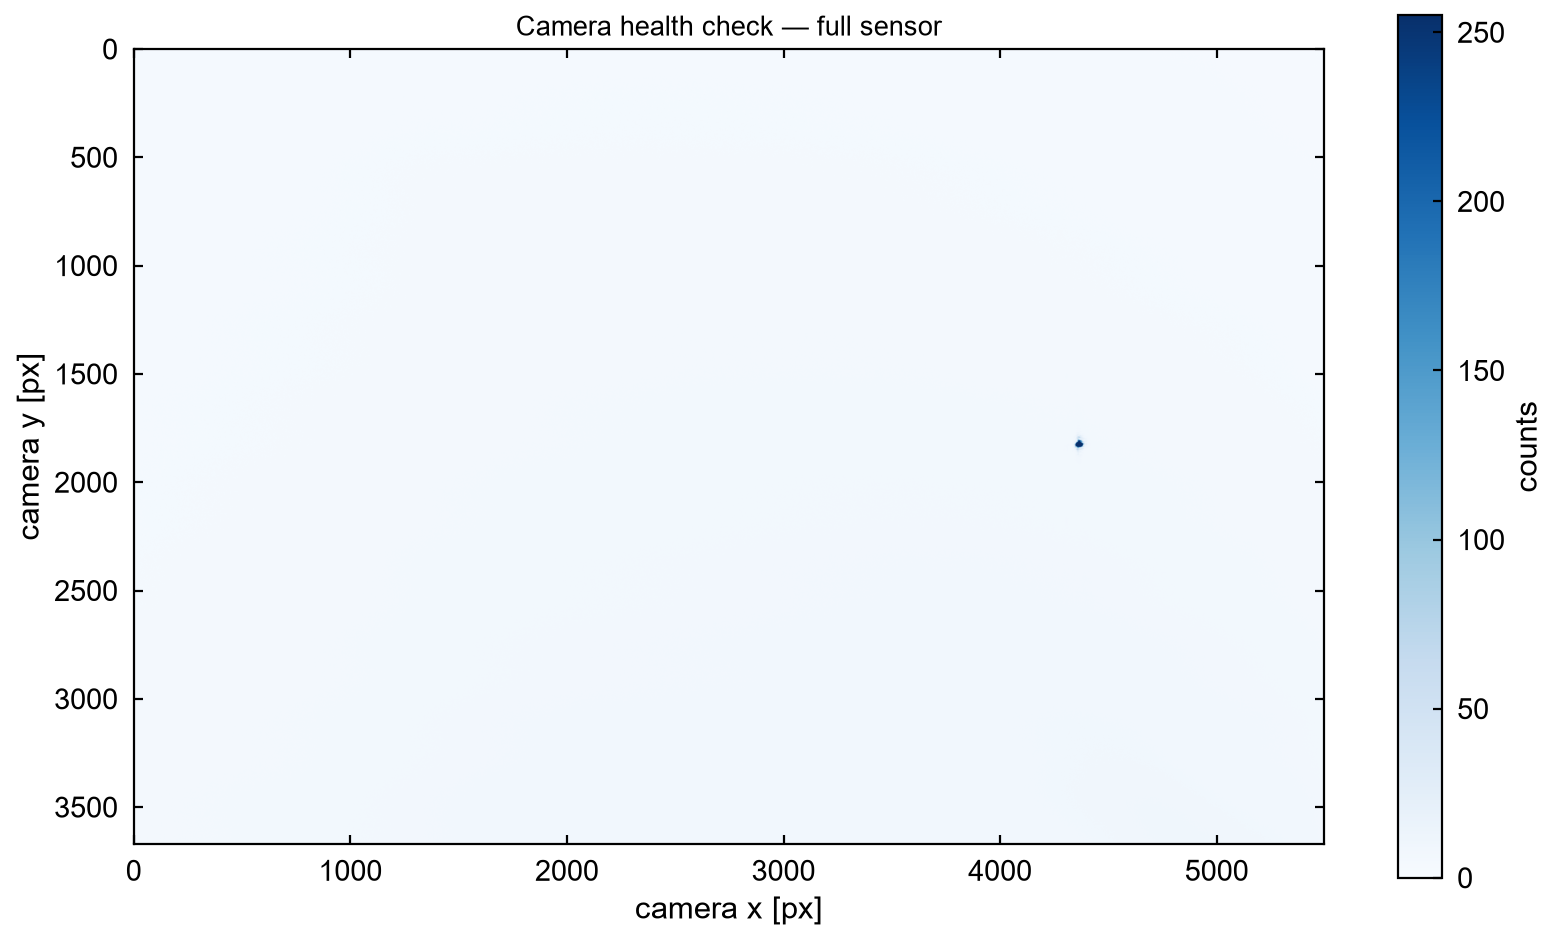

In [3]:
# ============================================================
# CAMERA HEALTH CHECK — one fresh full-frame image
# ============================================================

cam.set_exposure(0.005)   # 5 ms, deliberately conservative

cam.flush()
img_test = cam.get_image()

max_yx = np.unravel_index(np.argmax(img_test), img_test.shape)

print("Exposure [s]:", cam.exposure_s)
print("Image min   :", img_test.min())
print("Image max   :", img_test.max())
print("Image mean  :", img_test.mean())
print("Max at [y,x]:", max_yx)

plt.figure(figsize=(12, 7))
plt.imshow(img_test, origin="upper", vmin=0, vmax=max(5, img_test.max()))
plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title("Camera health check — full sensor")
plt.colorbar(label="counts")
plt.show()

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\toolbox\__init__.py:258: UserWarning: CameraSLM must be passed as slm for conversion 'kxy' to 'ij'
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

Exposure [s]: 0.000992181
Image min   : 0
Image max   : 226
Image mean  : 0.7246654726907745
Max at [y,x]: (np.int64(1824), np.int64(4361))


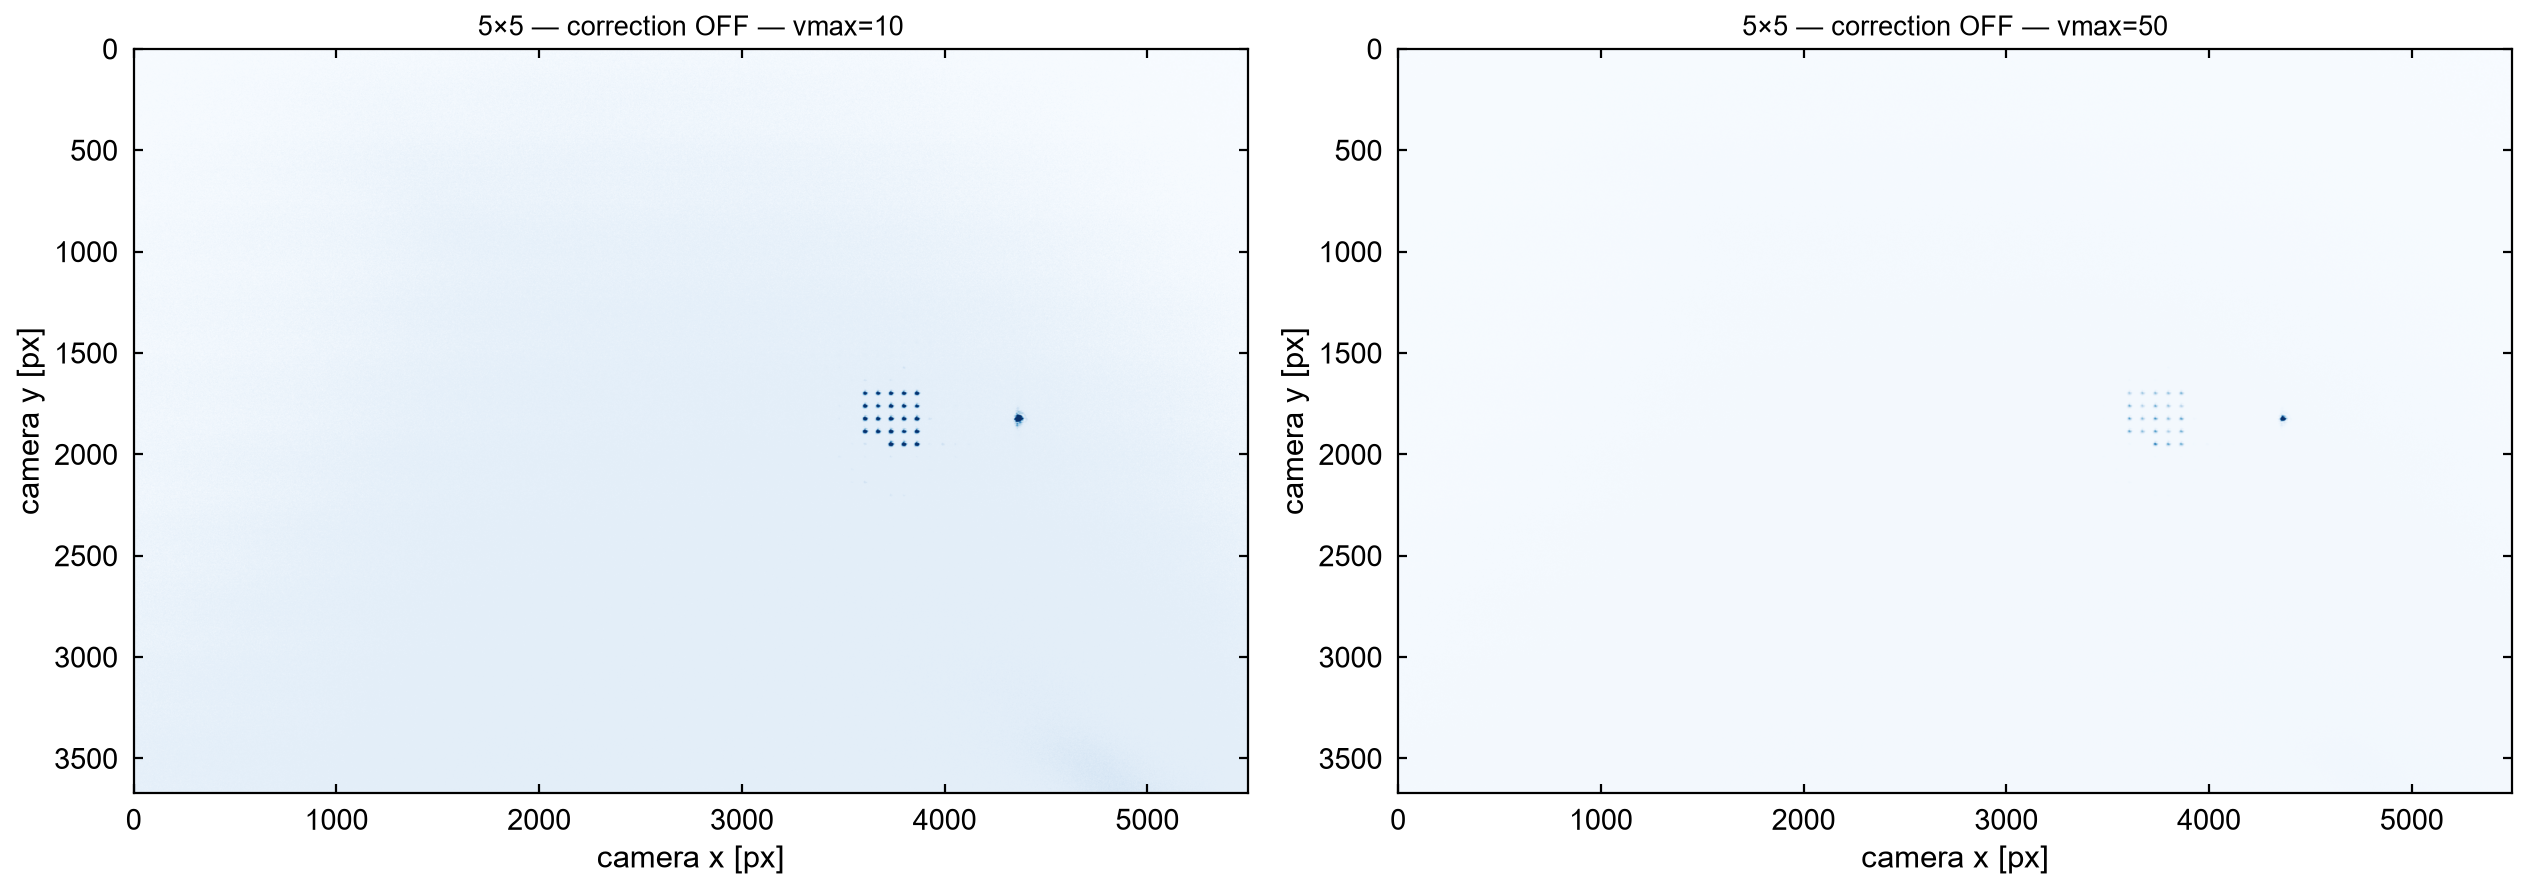

In [4]:
# ============================================================
# DISPLAY OLD 5×5 FOURIER GRID — NO WAVEFRONT CORRECTION
# Search the entire camera sensor
# ============================================================

cam.set_exposure(0.001)   # 1 ms for now

# Generate the same old Fourier calibration hologram
holo_5x5 = fs.fourier_grid_project(
    array_shape=(5, 5),
    array_pitch=(13, 13),
    array_center=(128, 0),
    method="GS",
    maxiter=10,
)

# IMPORTANT:
# overwrite what fourier_grid_project displayed
# and explicitly turn wavefront correction OFF
phase_5x5 = holo_5x5.get_phase()

slm.set_phase(
    phase_5x5,
    phase_correct=False,
    settle=True
)

cam.flush()
img_5x5_off = cam.get_image()

max_yx = np.unravel_index(np.argmax(img_5x5_off), img_5x5_off.shape)

print("Exposure [s]:", cam.exposure_s)
print("Image min   :", img_5x5_off.min())
print("Image max   :", img_5x5_off.max())
print("Image mean  :", img_5x5_off.mean())
print("Max at [y,x]:", max_yx)

# Full-frame view with low ceiling so weak spots are visible
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].imshow(
    img_5x5_off,
    origin="upper",
    vmin=0,
    vmax=10
)
axs[0].set_title("5×5 — correction OFF — vmax=10")
axs[0].set_xlabel("camera x [px]")
axs[0].set_ylabel("camera y [px]")

axs[1].imshow(
    img_5x5_off,
    origin="upper",
    vmin=0,
    vmax=50
)
axs[1].set_title("5×5 — correction OFF — vmax=50")
axs[1].set_xlabel("camera x [px]")
axs[1].set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

Loaded correction shape: (1200, 1920)
Finite: True

Exposure [s]: 0.000992181
Image max   : 222
Image mean  : 0.741335994409085
Max at [y,x]: (np.int64(1826), np.int64(4361))


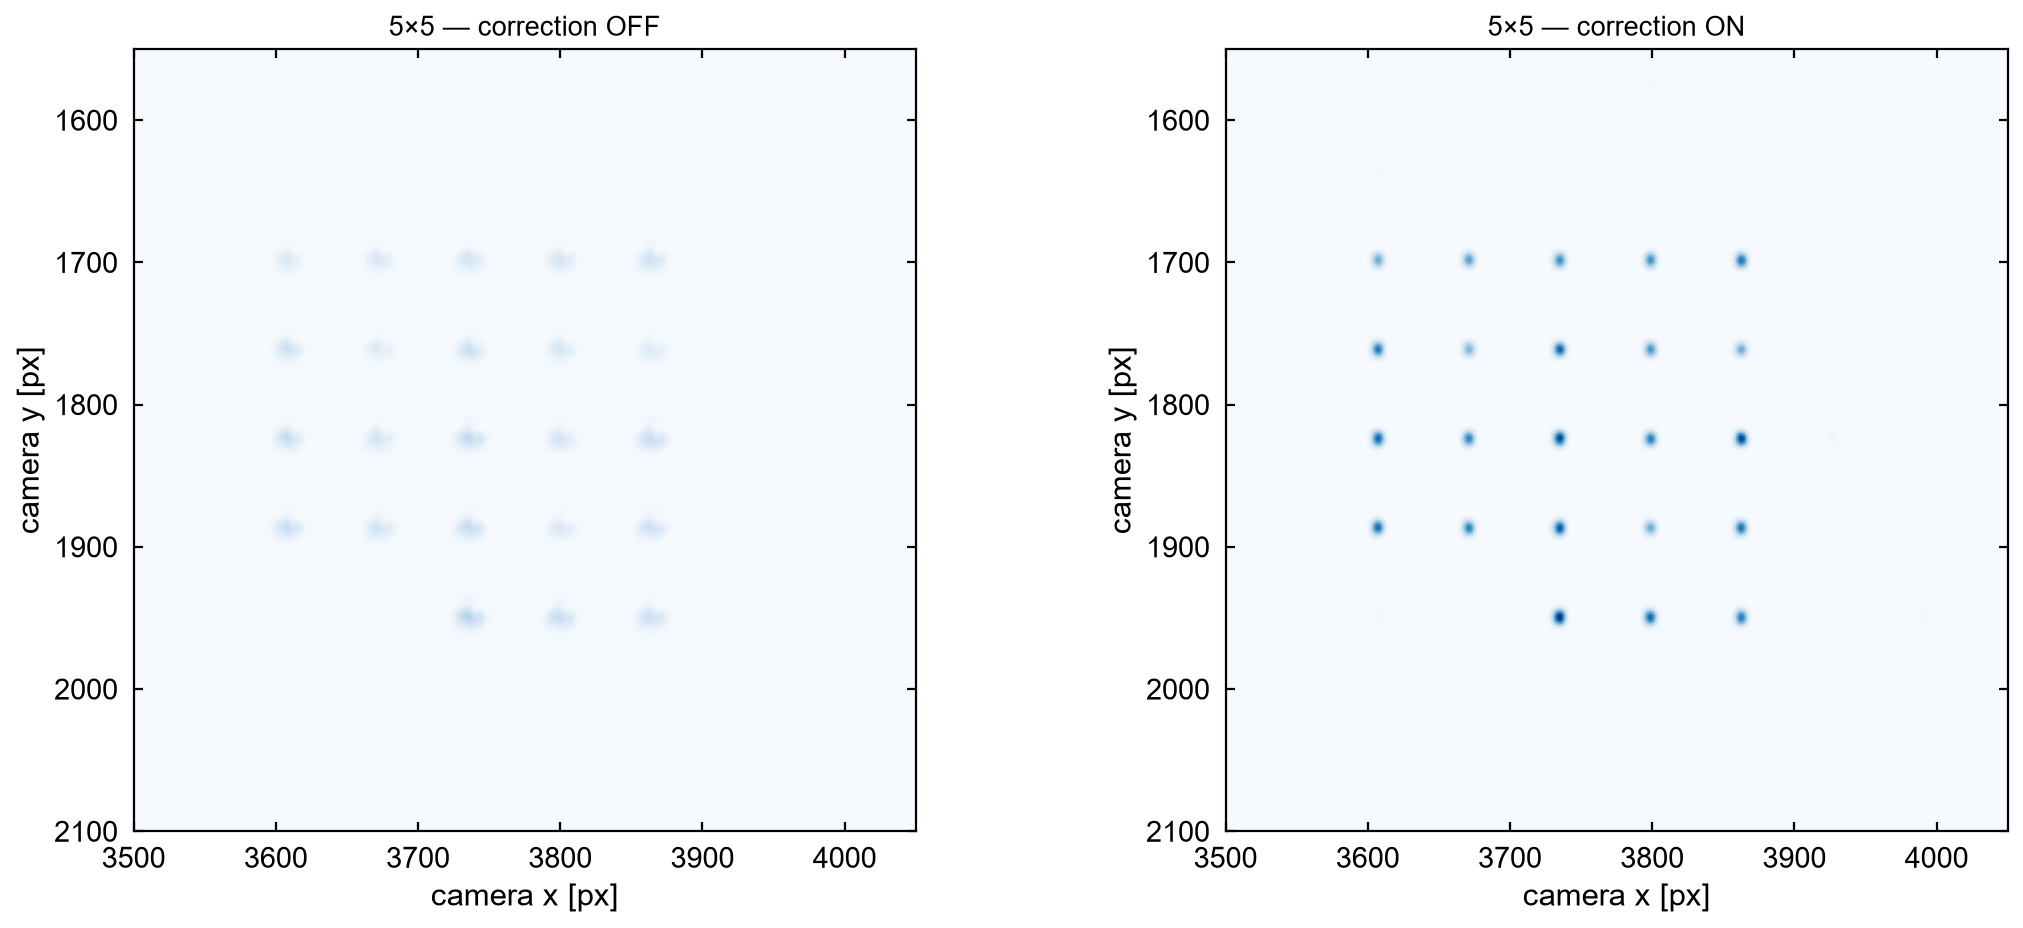


5×5 ROI max:
OFF: 41
ON : 131

5×5 ROI total counts:
OFF: 409109.0
ON : 440471.0


In [5]:
# ============================================================
# SAME EXACT 5×5 HOLOGRAM — WAVEFRONT CORRECTION ON
# ============================================================

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)

print("Loaded correction shape:", wavefront_phase.shape)
print("Finite:", np.all(np.isfinite(wavefront_phase)))

# Install measured phase correction
slm.source["phase"] = wavefront_phase

# Display the SAME 5×5 phase as before, now with correction ON
slm.set_phase(
    phase_5x5,
    phase_correct=True,
    settle=True
)

cam.flush()
img_5x5_on = cam.get_image()

max_yx = np.unravel_index(np.argmax(img_5x5_on), img_5x5_on.shape)

print("\nExposure [s]:", cam.exposure_s)
print("Image max   :", img_5x5_on.max())
print("Image mean  :", img_5x5_on.mean())
print("Max at [y,x]:", max_yx)

# Expected 5×5 region
x0, x1 = 3500, 4050
y0, y1 = 1550, 2100

roi_off = img_5x5_off[y0:y1, x0:x1]
roi_on  = img_5x5_on[y0:y1, x0:x1]

vmax = max(roi_off.max(), roi_on.max())

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].imshow(
    roi_off,
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[0].set_title("5×5 — correction OFF")

axs[1].imshow(
    roi_on,
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[1].set_title("5×5 — correction ON")

for ax in axs:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

print("\n5×5 ROI max:")
print("OFF:", roi_off.max())
print("ON :", roi_on.max())

print("\n5×5 ROI total counts:")
print("OFF:", roi_off.astype(float).sum())
print("ON :", roi_on.astype(float).sum())

Number of detected spots: 23

PEAK INTENSITY
Median OFF: 27.0
Median ON : 98.0
Median ON/OFF gain: 3.5

RMS WIDTH x
Median OFF: 5.987908450047197
Median ON : 4.183702715086016
Median ON/OFF: 0.6662456996058754

RMS WIDTH y
Median OFF: 5.546309639855065
Median ON : 4.643866663471451
Median ON/OFF: 0.7782373625770262


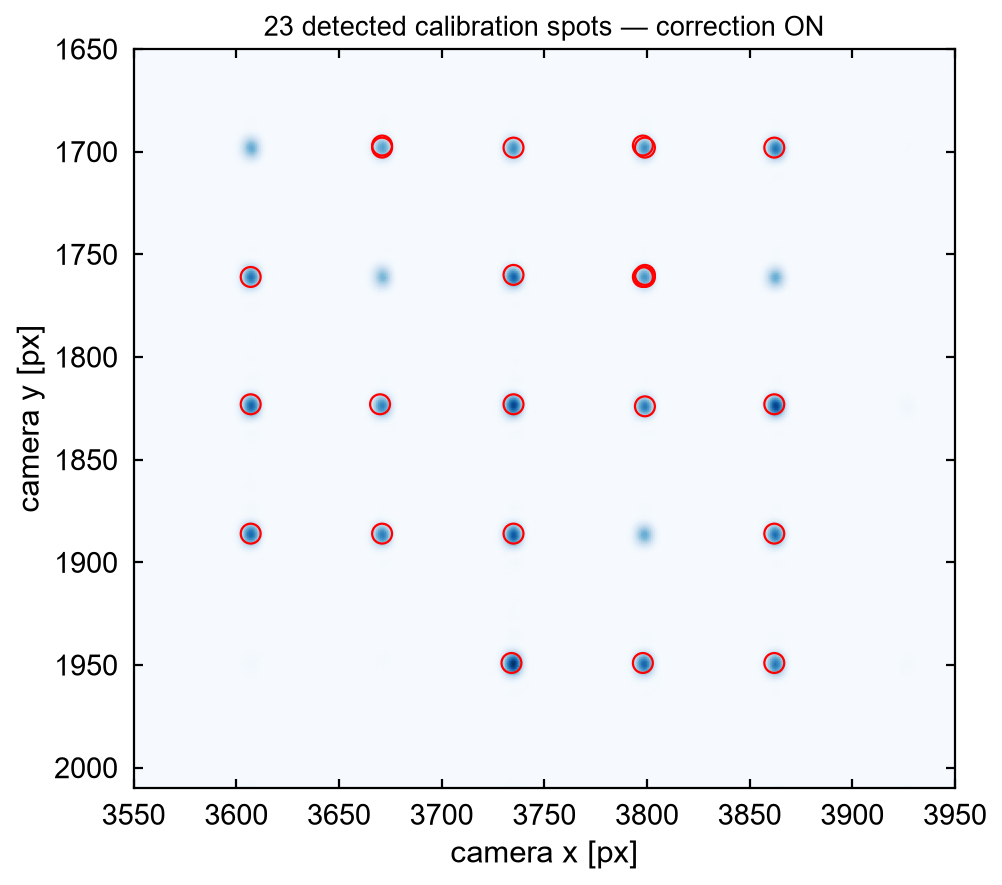

In [6]:
# ============================================================
# QUANTIFY 5×5 IMPROVEMENT — correction OFF vs ON
# Uses images already acquired. Nothing is written to SLM.
# ============================================================

from scipy.ndimage import maximum_filter
import numpy as np
import matplotlib.pyplot as plt

# ROI containing only the calibration grid
x0, x1 = 3550, 3950
y0, y1 = 1650, 2010

off = img_5x5_off[y0:y1, x0:x1].astype(float)
on  = img_5x5_on [y0:y1, x0:x1].astype(float)

# ------------------------------------------------------------
# Find the 23 local maxima from the corrected image.
# The spots are ~60 px apart, so a 35-px neighborhood is safe.
# ------------------------------------------------------------

local_max = on == maximum_filter(on, size=35)

coords = np.argwhere(local_max)

# Sort candidate maxima by intensity
vals = on[coords[:, 0], coords[:, 1]]
order = np.argsort(vals)[::-1]

coords = coords[order]

# Keep the 23 strongest peaks
coords = coords[:23]

# Sort for nicer plotting
coords = coords[np.lexsort((coords[:, 1], coords[:, 0]))]


# ------------------------------------------------------------
# Measure each spot in a ±15 px box.
# Calculate peak and second-moment RMS width.
# ------------------------------------------------------------

halfbox = 15

results = []

for yy, xx in coords:

    ys = slice(max(0, yy-halfbox), min(on.shape[0], yy+halfbox+1))
    xs = slice(max(0, xx-halfbox), min(on.shape[1], xx+halfbox+1))

    patch_off = off[ys, xs]
    patch_on  = on [ys, xs]

    Y, X = np.indices(patch_on.shape)

    def measure(patch):
        # Remove local minimum as simple background estimate
        p = patch - np.min(patch)
        p[p < 0] = 0

        total = np.sum(p)

        if total <= 0:
            return np.nan, np.nan, np.nan

        xc = np.sum(X * p) / total
        yc = np.sum(Y * p) / total

        sx = np.sqrt(np.sum(((X-xc)**2) * p) / total)
        sy = np.sqrt(np.sum(((Y-yc)**2) * p) / total)

        return np.max(p), sx, sy

    peak_off, sx_off, sy_off = measure(patch_off)
    peak_on,  sx_on,  sy_on  = measure(patch_on)

    results.append(
        [peak_off, peak_on, sx_off, sx_on, sy_off, sy_on]
    )

results = np.asarray(results)

peak_gain = results[:,1] / results[:,0]
sx_ratio  = results[:,3] / results[:,2]
sy_ratio  = results[:,5] / results[:,4]

print("Number of detected spots:", len(results))

print("\nPEAK INTENSITY")
print("Median OFF:", np.median(results[:,0]))
print("Median ON :", np.median(results[:,1]))
print("Median ON/OFF gain:", np.median(peak_gain))

print("\nRMS WIDTH x")
print("Median OFF:", np.median(results[:,2]))
print("Median ON :", np.median(results[:,3]))
print("Median ON/OFF:", np.median(sx_ratio))

print("\nRMS WIDTH y")
print("Median OFF:", np.median(results[:,4]))
print("Median ON :", np.median(results[:,5]))
print("Median ON/OFF:", np.median(sy_ratio))


# ------------------------------------------------------------
# Show detected spot centers
# ------------------------------------------------------------

plt.figure(figsize=(7,6))
plt.imshow(
    on,
    origin="upper",
    extent=[x0, x1, y1, y0]
)

plt.scatter(
    coords[:,1] + x0,
    coords[:,0] + y0,
    facecolors="none",
    edgecolors="red",
    s=80
)

plt.title("23 detected calibration spots — correction ON")
plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.show()



CORRECTION OFF
max : 225
max [y,x]: (np.int64(1824), np.int64(4360))

CORRECTION ON
max : 255
max [y,x]: (np.int64(1820), np.int64(3732))


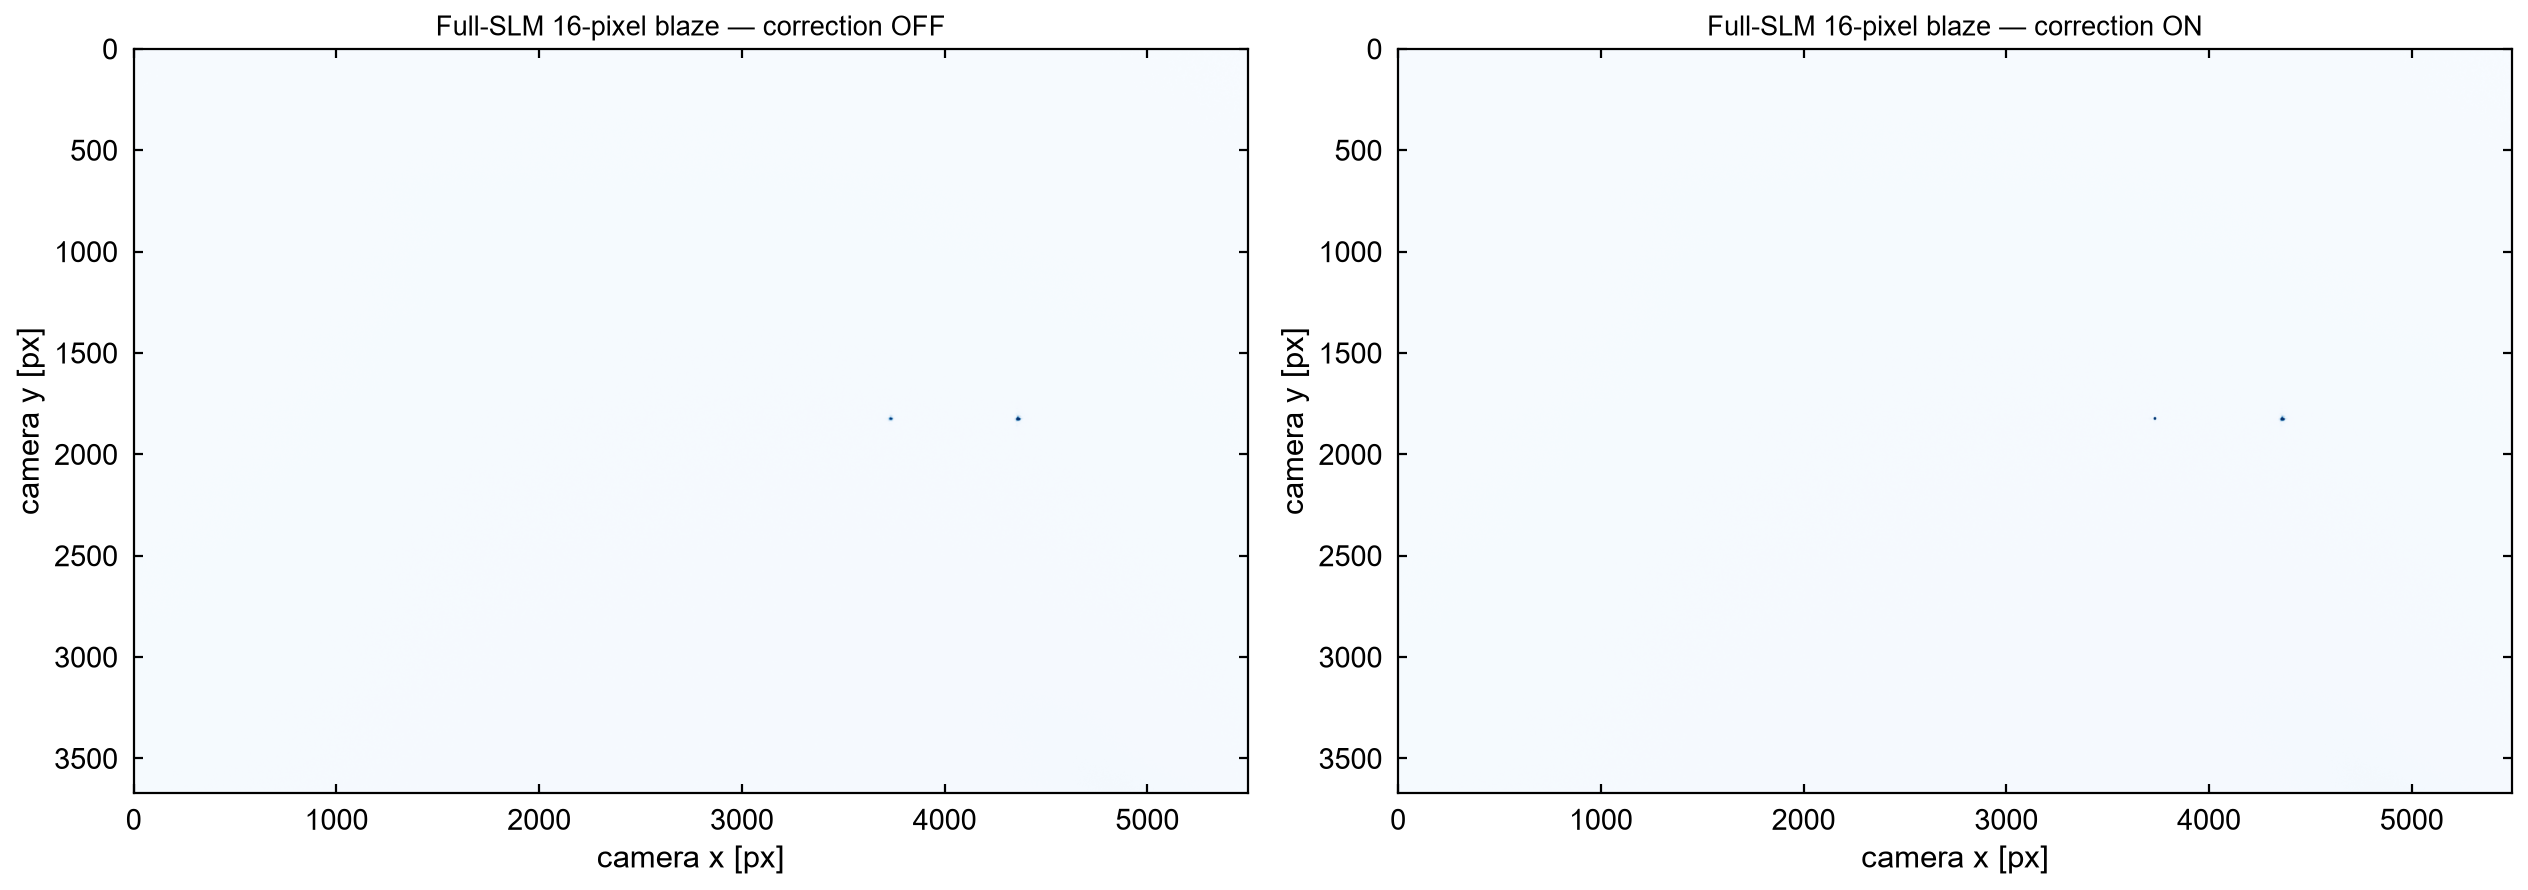

In [7]:
# ============================================================
# FULL-SLM 16-PIXEL BLAZE — correction OFF vs ON
# Same exact blaze in both cases
# ============================================================

# Pure 16-pixel blaze across the full SLM
yy, xx = np.indices(slm.shape)

phase_blaze_16 = 2 * np.pi * xx / 16.0


def acquire_blaze(phase_correct):

    slm.set_phase(
        phase_blaze_16,
        phase_correct=phase_correct,
        settle=True
    )

    cam.flush()
    img = cam.get_image()

    return img


# ------------------------------------------------------------
# Acquire OFF and ON
# ------------------------------------------------------------

img_blaze_off = acquire_blaze(False)
img_blaze_on  = acquire_blaze(True)


print("CORRECTION OFF")
print("max :", img_blaze_off.max())
print("max [y,x]:",
      np.unravel_index(np.argmax(img_blaze_off), img_blaze_off.shape))

print("\nCORRECTION ON")
print("max :", img_blaze_on.max())
print("max [y,x]:",
      np.unravel_index(np.argmax(img_blaze_on), img_blaze_on.shape))


# ------------------------------------------------------------
# Show full camera first
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].imshow(
    img_blaze_off,
    origin="upper",
    vmin=0,
    vmax=min(100, img_blaze_off.max())
)
axs[0].set_title("Full-SLM 16-pixel blaze — correction OFF")

axs[1].imshow(
    img_blaze_on,
    origin="upper",
    vmin=0,
    vmax=min(100, img_blaze_on.max())
)
axs[1].set_title("Full-SLM 16-pixel blaze — correction ON")

for ax in axs:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

Exposure [s]: 0.000249681

CORRECTION OFF
ROI raw max       : 122.0
background        : 0.0
peak above bg     : 122.0
integrated counts : 23527.0
centroid [x,y]    : 3733.082500956348 1823.2027457814427
sigma_x [px]      : 5.974623891363321
sigma_y [px]      : 7.531560104799821
ellipticity       : 1.260591501949963

CORRECTION ON
ROI raw max       : 255.0
background        : 0.0
peak above bg     : 255.0
integrated counts : 27831.0
centroid [x,y]    : 3732.9538643958176 1823.6905608853438
sigma_x [px]      : 3.615054626420496
sigma_y [px]      : 4.345103225675178
ellipticity       : 1.2019467683611607

ON / OFF
peak gain         : 2.0901639344262297
power ratio       : 1.1829387512220002
sigma_x ratio     : 0.6050681502556631
sigma_y ratio     : 0.5769194118103191


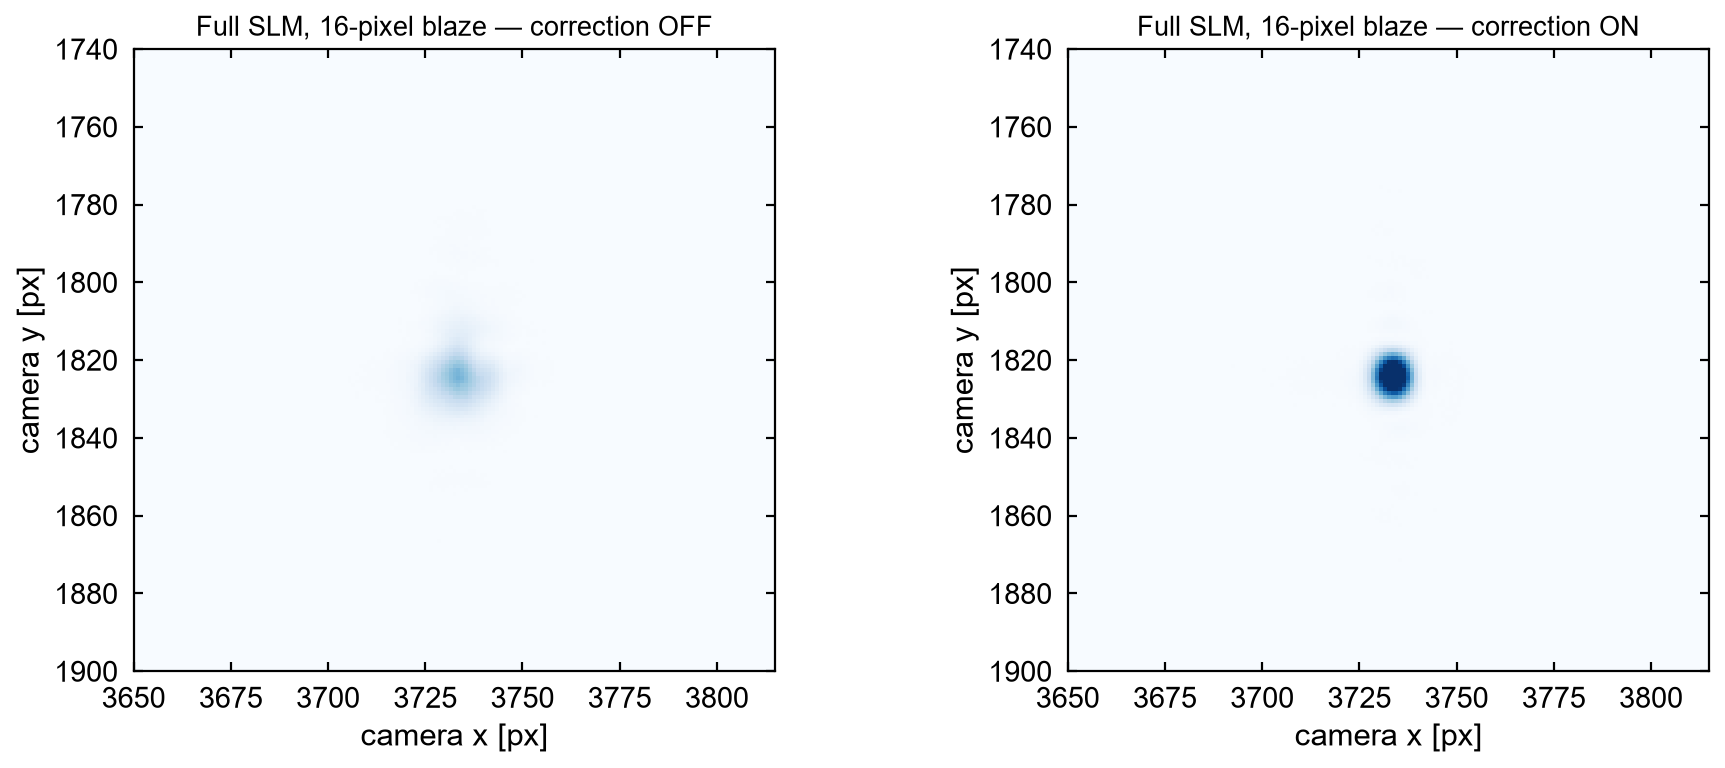

In [ ]:
# ============================================================
# FULL-SLM 16-PIXEL BLAZE — quantitative carrier comparison
# correction OFF vs ON
# ============================================================

cam.set_exposure(0.00025)   # 0.25 ms, avoid saturation

# Carrier ROI
x0, x1 = 3650, 3815
y0, y1 = 1740, 1900


def acquire_and_measure(phase_correct):

    slm.set_phase(
        phase_blaze_16,
        phase_correct=phase_correct,
        settle=True
    )

    cam.flush()
    img = cam.get_image()

    roi = img[y0:y1, x0:x1].astype(float)

    # Background from outer border of ROI
    border = np.concatenate([
        roi[0, :],
        roi[-1, :],
        roi[:, 0],
        roi[:, -1]
    ])

    background = np.median(border)

    p = roi - background
    p[p < 0] = 0

    Y, X = np.indices(p.shape)

    total = np.sum(p)

    xc = np.sum(X * p) / total
    yc = np.sum(Y * p) / total

    sx = np.sqrt(np.sum((X - xc)**2 * p) / total)
    sy = np.sqrt(np.sum((Y - yc)**2 * p) / total)

    peak = np.max(p)

    return {
        "img": img,
        "roi": roi,
        "p": p,
        "background": background,
        "peak": peak,
        "total": total,
        "xc": xc + x0,
        "yc": yc + y0,
        "sx": sx,
        "sy": sy,
        "ellipticity": max(sx, sy) / min(sx, sy),
    }


off = acquire_and_measure(False)
on  = acquire_and_measure(True)


print("Exposure [s]:", cam.exposure_s)

print("\nCORRECTION OFF")
print("ROI raw max       :", off["roi"].max())
print("background        :", off["background"])
print("peak above bg     :", off["peak"])
print("integrated counts :", off["total"])
print("centroid [x,y]    :", off["xc"], off["yc"])
print("sigma_x [px]      :", off["sx"])
print("sigma_y [px]      :", off["sy"])
print("ellipticity       :", off["ellipticity"])

print("\nCORRECTION ON")
print("ROI raw max       :", on["roi"].max())
print("background        :", on["background"])
print("peak above bg     :", on["peak"])
print("integrated counts :", on["total"])
print("centroid [x,y]    :", on["xc"], on["yc"])
print("sigma_x [px]      :", on["sx"])
print("sigma_y [px]      :", on["sy"])
print("ellipticity       :", on["ellipticity"])

print("\nON / OFF")
print("peak gain         :", on["peak"] / off["peak"])
print("power ratio       :", on["total"] / off["total"])
print("sigma_x ratio     :", on["sx"] / off["sx"])
print("sigma_y ratio     :", on["sy"] / off["sy"])


# Same display scale
vmax = max(off["p"].max(), on["p"].max())

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(
    off["p"],
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[0].set_title("Full SLM, 16-pixel blaze — correction OFF")

axs[1].imshow(
    on["p"],
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[1].set_title("Full SLM, 16-pixel blaze — correction ON")

for ax in axs:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

Exposure [s]: 0.000112181

CORRECTION OFF
raw max       : 51.0
centroid [x,y]: 3733.6674911280784 1822.6090977524466
sigma_x [px]  : 5.837807462962689
sigma_y [px]  : 5.74618235998286
ellipticity   : 1.0159453872570976
total counts  : 9299.0

CORRECTION ON
raw max       : 138.0
centroid [x,y]: 3732.557889291257 1822.767408173823
sigma_x [px]  : 3.0419699307607435
sigma_y [px]  : 3.5199106061221177
ellipticity   : 1.157115516010985
total counts  : 9665.0

ON / OFF
peak gain     : 2.7058823529411766
power ratio   : 1.0393590708678353
sigma_x ratio : 0.5210808938218978
sigma_y ratio : 0.6125650711392698

GOOD: both spots are safely below saturation.


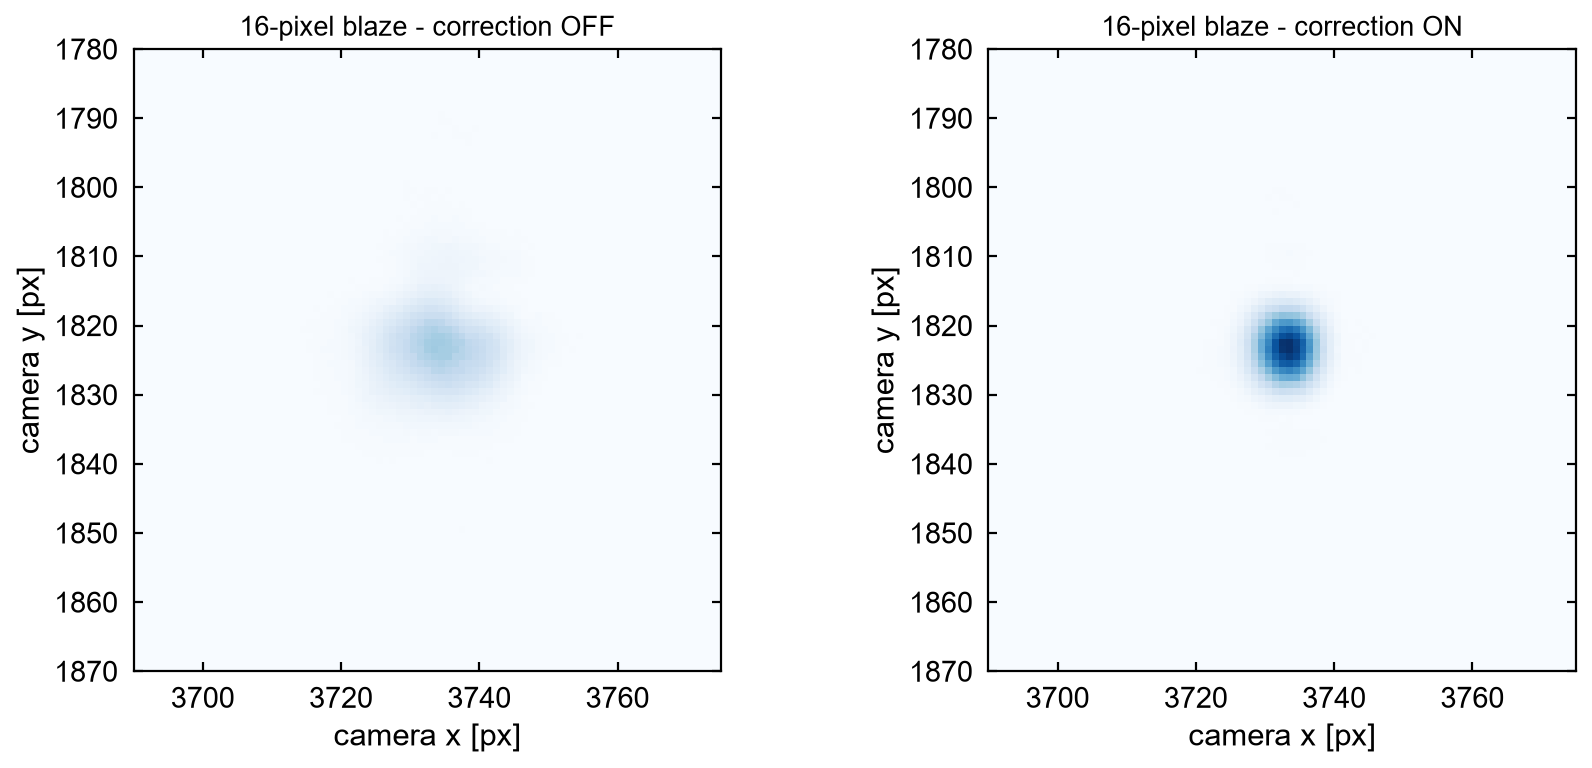

In [10]:
# ============================================================
# TIGHT 16-PIXEL-CARRIER CHECK
# Re-run this cell after each manual laser-power adjustment
# ============================================================

EXPOSURE_S = 0.00010      # 0.10 ms = 100 us

# Tight ROI around carrier ~ (3733, 1824)
x0, x1 = 3690, 3775
y0, y1 = 1780, 1870

cam.set_exposure(EXPOSURE_S)


def acquire_carrier(phase_correct):

    slm.set_phase(
        phase_blaze_16,
        phase_correct=phase_correct,
        settle=True
    )

    cam.flush()
    img = cam.get_image()

    roi = img[y0:y1, x0:x1].astype(float)

    # Estimate background from ROI border
    border = np.concatenate([
        roi[0, :],
        roi[-1, :],
        roi[:, 0],
        roi[:, -1]
    ])

    bg = np.median(border)

    p = roi - bg
    p[p < 0] = 0

    Y, X = np.indices(p.shape)
    total = p.sum()

    xc = np.sum(X * p) / total
    yc = np.sum(Y * p) / total

    sx = np.sqrt(np.sum((X - xc)**2 * p) / total)
    sy = np.sqrt(np.sum((Y - yc)**2 * p) / total)

    return {
        "roi": roi,
        "p": p,
        "peak_raw": roi.max(),
        "peak": p.max(),
        "total": total,
        "xc": xc + x0,
        "yc": yc + y0,
        "sx": sx,
        "sy": sy,
        "ellipticity": max(sx, sy) / min(sx, sy),
    }


off = acquire_carrier(False)
on  = acquire_carrier(True)


print("Exposure [s]:", cam.exposure_s)

print("\nCORRECTION OFF")
print("raw max       :", off["peak_raw"])
print("centroid [x,y]:", off["xc"], off["yc"])
print("sigma_x [px]  :", off["sx"])
print("sigma_y [px]  :", off["sy"])
print("ellipticity   :", off["ellipticity"])
print("total counts  :", off["total"])

print("\nCORRECTION ON")
print("raw max       :", on["peak_raw"])
print("centroid [x,y]:", on["xc"], on["yc"])
print("sigma_x [px]  :", on["sx"])
print("sigma_y [px]  :", on["sy"])
print("ellipticity   :", on["ellipticity"])
print("total counts  :", on["total"])

print("\nON / OFF")
print("peak gain     :", on["peak"] / off["peak"])
print("power ratio   :", on["total"] / off["total"])
print("sigma_x ratio :", on["sx"] / off["sx"])
print("sigma_y ratio :", on["sy"] / off["sy"])

if off["peak_raw"] >= 245 or on["peak_raw"] >= 245:
    print("\nWARNING: still too close to saturation — reduce laser power.")
else:
    print("\nGOOD: both spots are safely below saturation.")


# Same display scale for a fair visual comparison
vmax = max(off["p"].max(), on["p"].max())

fig, axs = plt.subplots(1, 2, figsize=(11, 5))

axs[0].imshow(
    off["p"],
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[0].set_title("16-pixel blaze - correction OFF")

axs[1].imshow(
    on["p"],
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)
axs[1].set_title("16-pixel blaze - correction ON")

for ax in axs:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

CORRECTION OFF
sigma_x [px] : 6.0529122682952
sigma_y [px] : 4.854610673737947
FWHM_x [px]  : 14.253519140195289
FWHM_y [px]  : 11.431734525339321
ellipticity  : 1.2468378362532182

CORRECTION ON
sigma_x [px] : 3.087812028270955
sigma_y [px] : 3.515047544575011
FWHM_x [px]  : 7.271241659460117
FWHM_y [px]  : 8.277304417202055
ellipticity  : 1.1383618926257275

ON / OFF
FWHM_x ratio : 0.5101365906862277
FWHM_y ratio : 0.7240637366844701
peak-fit gain: 2.9479342105343713


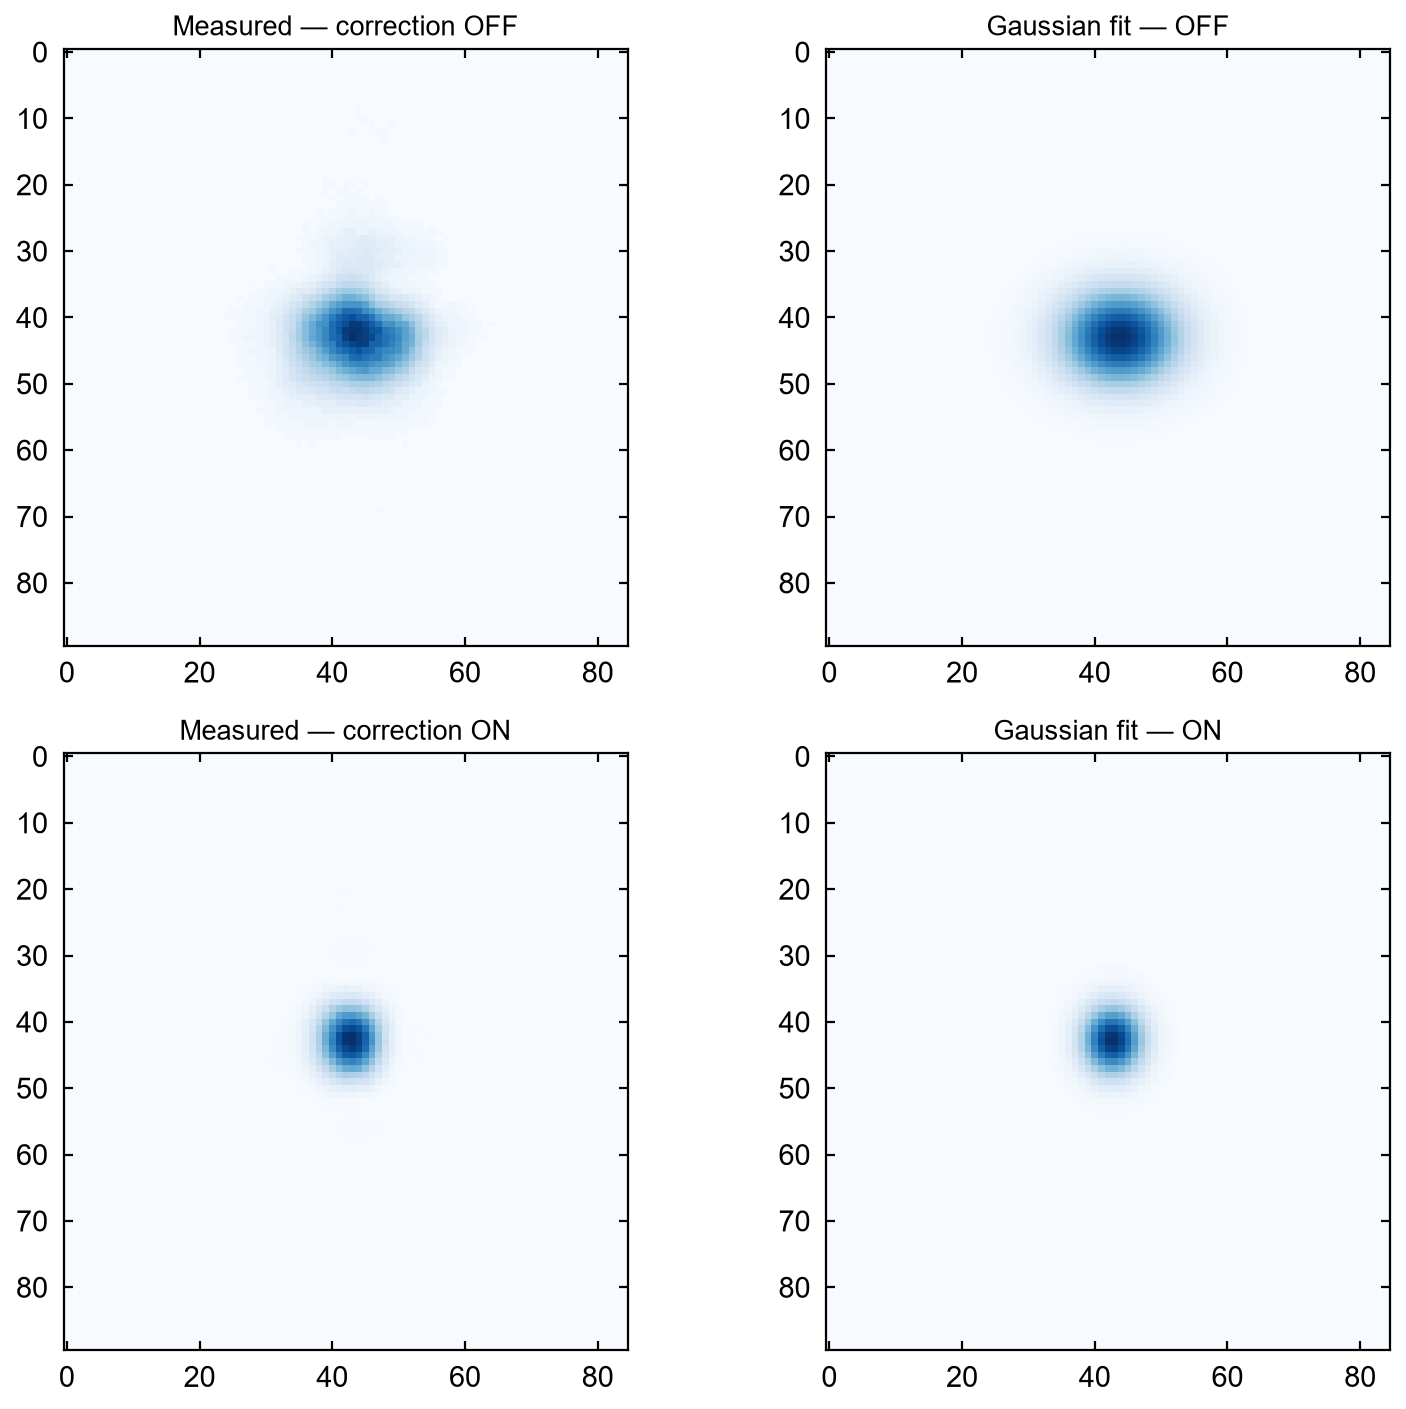

In [11]:
# ============================================================
# 2D GAUSSIAN FIT TO CENTRAL CORE — OFF vs ON
# Uses the already-acquired 'off' and 'on' ROI data
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian2d(coords, A, x0, y0, sx, sy, bg):
    X, Y = coords

    g = (
        bg
        + A * np.exp(
            -0.5 * (
                ((X - x0) / sx)**2
                + ((Y - y0) / sy)**2
            )
        )
    )

    return g.ravel()


def fit_spot(roi):

    roi = np.asarray(roi, dtype=float)

    Y, X = np.indices(roi.shape)

    iy, ix = np.unravel_index(np.argmax(roi), roi.shape)

    bg0 = np.median(
        np.concatenate([
            roi[0, :],
            roi[-1, :],
            roi[:, 0],
            roi[:, -1]
        ])
    )

    A0 = roi.max() - bg0

    p0 = [
        A0,
        ix,
        iy,
        4.0,
        4.0,
        bg0
    ]

    bounds = (
        [0, 0, 0, 0.3, 0.3, -np.inf],
        [
            np.inf,
            roi.shape[1],
            roi.shape[0],
            30,
            30,
            np.inf
        ]
    )

    popt, pcov = curve_fit(
        gaussian2d,
        (X, Y),
        roi.ravel(),
        p0=p0,
        bounds=bounds,
        maxfev=20000
    )

    fit = gaussian2d((X, Y), *popt).reshape(roi.shape)

    return popt, fit


fit_off, model_off = fit_spot(off["roi"])
fit_on,  model_on  = fit_spot(on["roi"])

A_off, xc_off, yc_off, sx_off, sy_off, bg_off = fit_off
A_on,  xc_on,  yc_on,  sx_on,  sy_on,  bg_on  = fit_on

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2))

print("CORRECTION OFF")
print("sigma_x [px] :", sx_off)
print("sigma_y [px] :", sy_off)
print("FWHM_x [px]  :", FWHM_FACTOR * sx_off)
print("FWHM_y [px]  :", FWHM_FACTOR * sy_off)
print("ellipticity  :", max(sx_off, sy_off) / min(sx_off, sy_off))

print("\nCORRECTION ON")
print("sigma_x [px] :", sx_on)
print("sigma_y [px] :", sy_on)
print("FWHM_x [px]  :", FWHM_FACTOR * sx_on)
print("FWHM_y [px]  :", FWHM_FACTOR * sy_on)
print("ellipticity  :", max(sx_on, sy_on) / min(sx_on, sy_on))

print("\nON / OFF")
print("FWHM_x ratio :", sx_on / sx_off)
print("FWHM_y ratio :", sy_on / sy_off)
print("peak-fit gain:", A_on / A_off)


fig, axs = plt.subplots(2, 2, figsize=(10, 9))

axs[0,0].imshow(off["roi"], origin="upper")
axs[0,0].set_title("Measured — correction OFF")

axs[0,1].imshow(model_off, origin="upper")
axs[0,1].set_title("Gaussian fit — OFF")

axs[1,0].imshow(on["roi"], origin="upper")
axs[1,0].set_title("Measured — correction ON")

axs[1,1].imshow(model_on, origin="upper")
axs[1,1].set_title("Gaussian fit — ON")

plt.tight_layout()
plt.show()

In [ ]:
# The plots are nice and awesome. I would just like to have better data with more statistics. I want to have the following data for the wiki/for saving:

# full SLM 16-pixel blaze, correction OFF vs ON
# 5x5 Fourier grid, correction OFF vs ON
# 10x10 Fourier grid, correction OFF vs ON

# with all required statistics: peak, total counts, sigma_x, sigma_y, ellipticity, etc.

# keep the plots black and white in colormap


In [14]:
# ============================================================
# WAVEFRONT VALIDATION — reusable acquisition/analysis tools
#
# Experiments:
#   1. Full-SLM 16-pixel blaze
#   2. 5x5 Fourier grid
#   3. 10x10 Fourier grid
#
# OFF/ON measurements use EXACTLY the same hologram phase.
# All image plots use grayscale.
# ============================================================

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.ndimage import maximum_filter


# ------------------------------------------------------------
# DATA DIRECTORY
# ------------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

VALIDATION_DIR = (
    WAVEFRONT_PHASE_PATH.parent /
    f"wavefront_validation_{timestamp}"
)

VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

print("Validation data will be saved to:")
print(VALIDATION_DIR)


# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------

CAMERA_PIXEL_UM = 2.4

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2))


# ------------------------------------------------------------
# 2D Gaussian
# ------------------------------------------------------------

def gaussian2d(coords, A, x0, y0, sx, sy, bg):

    X, Y = coords

    model = (
        bg
        + A * np.exp(
            -0.5 * (
                ((X - x0) / sx)**2
                + ((Y - y0) / sy)**2
            )
        )
    )

    return model.ravel()


# ------------------------------------------------------------
# Fit one spot
# ------------------------------------------------------------

def fit_single_spot(patch):

    patch = np.asarray(patch, dtype=float)

    Y, X = np.indices(patch.shape)

    iy, ix = np.unravel_index(
        np.argmax(patch),
        patch.shape
    )

    # Border background estimate
    border = np.concatenate([
        patch[0, :],
        patch[-1, :],
        patch[:, 0],
        patch[:, -1]
    ])

    bg_est = np.median(border)

    corrected = patch - bg_est
    corrected[corrected < 0] = 0

    total_counts = corrected.sum()

    raw_peak = patch.max()

    if total_counts <= 0:

        return {
            "fit_success": False,
            "raw_peak": raw_peak,
            "fit_peak": np.nan,
            "background": bg_est,
            "total_counts": total_counts,
            "x0": np.nan,
            "y0": np.nan,
            "sigma_x_px": np.nan,
            "sigma_y_px": np.nan,
            "fwhm_x_px": np.nan,
            "fwhm_y_px": np.nan,
            "fwhm_x_um": np.nan,
            "fwhm_y_um": np.nan,
            "ellipticity": np.nan,
            "saturated": raw_peak >= 250,
        }

    A0 = raw_peak - bg_est

    p0 = [
        max(A0, 1),
        ix,
        iy,
        3.5,
        3.5,
        bg_est
    ]

    bounds = (
        [0, 0, 0, 0.25, 0.25, -np.inf],
        [
            np.inf,
            patch.shape[1],
            patch.shape[0],
            30,
            30,
            np.inf
        ]
    )

    try:

        popt, _ = curve_fit(
            gaussian2d,
            (X, Y),
            patch.ravel(),
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )

        A, xc, yc, sx, sy, bg = popt

        fwhm_x = FWHM_FACTOR * sx
        fwhm_y = FWHM_FACTOR * sy

        ellipticity = max(sx, sy) / min(sx, sy)

        return {
            "fit_success": True,
            "raw_peak": raw_peak,
            "fit_peak": A,
            "background": bg,
            "total_counts": total_counts,

            "x0": xc,
            "y0": yc,

            "sigma_x_px": sx,
            "sigma_y_px": sy,

            "fwhm_x_px": fwhm_x,
            "fwhm_y_px": fwhm_y,

            "fwhm_x_um": fwhm_x * CAMERA_PIXEL_UM,
            "fwhm_y_um": fwhm_y * CAMERA_PIXEL_UM,

            "ellipticity": ellipticity,

            "saturated": raw_peak >= 250,
        }

    except Exception:

        return {
            "fit_success": False,
            "raw_peak": raw_peak,
            "fit_peak": np.nan,
            "background": bg_est,
            "total_counts": total_counts,
            "x0": np.nan,
            "y0": np.nan,
            "sigma_x_px": np.nan,
            "sigma_y_px": np.nan,
            "fwhm_x_px": np.nan,
            "fwhm_y_px": np.nan,
            "fwhm_x_um": np.nan,
            "fwhm_y_um": np.nan,
            "ellipticity": np.nan,
            "saturated": raw_peak >= 250,
        }


# ------------------------------------------------------------
# Acquire one ROI
# ------------------------------------------------------------

def acquire_roi(
    phase,
    phase_correct,
    roi
):

    x0, x1, y0, y1 = roi

    slm.set_phase(
        phase,
        phase_correct=phase_correct,
        settle=True
    )

    cam.flush()

    img = cam.get_image()

    return img[y0:y1, x0:x1].copy()


# ------------------------------------------------------------
# Detect array spots from MEAN corrected image
# ------------------------------------------------------------

def detect_spots(
    image,
    nspots,
    neighborhood=35
):

    filt = maximum_filter(
        image,
        size=neighborhood
    )

    candidates = np.argwhere(
        image == filt
    )

    values = image[
        candidates[:, 0],
        candidates[:, 1]
    ]

    order = np.argsort(values)[::-1]

    coords = candidates[order[:nspots]]

    # Sort approximately row-by-row
    coords = coords[
        np.lexsort(
            (
                coords[:, 1],
                coords[:, 0]
            )
        )
    ]

    return coords


# ------------------------------------------------------------
# Print statistics helper
# ------------------------------------------------------------

def metric_stats(values):

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    return {
        "N": len(values),
        "mean": np.mean(values),
        "std": np.std(values, ddof=1)
            if len(values) > 1 else 0,
        "median": np.median(values),
        "q25": np.percentile(values, 25),
        "q75": np.percentile(values, 75),
    }


print("\nAcquisition/analysis functions ready.")

Validation data will be saved to:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\wavefront_validation_20260904_111022

Acquisition/analysis functions ready.


Experiment: Full-SLM 16-pixel blaze
Repeats per state: 20
Exposure [s]: 2.9681000000000003e-05
ROI: (3690, 3775, 1780, 1870)

Repeat 01/20 order = OFF→ON
Repeat 02/20 order = ON→OFF
Repeat 03/20 order = OFF→ON
Repeat 04/20 order = ON→OFF
Repeat 05/20 order = OFF→ON
Repeat 06/20 order = ON→OFF
Repeat 07/20 order = OFF→ON
Repeat 08/20 order = ON→OFF
Repeat 09/20 order = OFF→ON
Repeat 10/20 order = ON→OFF
Repeat 11/20 order = OFF→ON
Repeat 12/20 order = ON→OFF
Repeat 13/20 order = OFF→ON
Repeat 14/20 order = ON→OFF
Repeat 15/20 order = OFF→ON
Repeat 16/20 order = ON→OFF
Repeat 17/20 order = OFF→ON
Repeat 18/20 order = ON→OFF
Repeat 19/20 order = OFF→ON
Repeat 20/20 order = ON→OFF

PAIRED ON / OFF RESULTS
raw_peak              median= 2.6957   mean= 2.6326 ±  0.4822
fit_peak              median= 2.9914   mean= 2.9731 ±  0.5148
total_counts          median= 1.0698   mean= 1.0717 ±  0.1800
sigma_x_px            median= 0.5333   mean= 0.5301 ±  0.0290
sigma_y_px            median= 0.7111   me

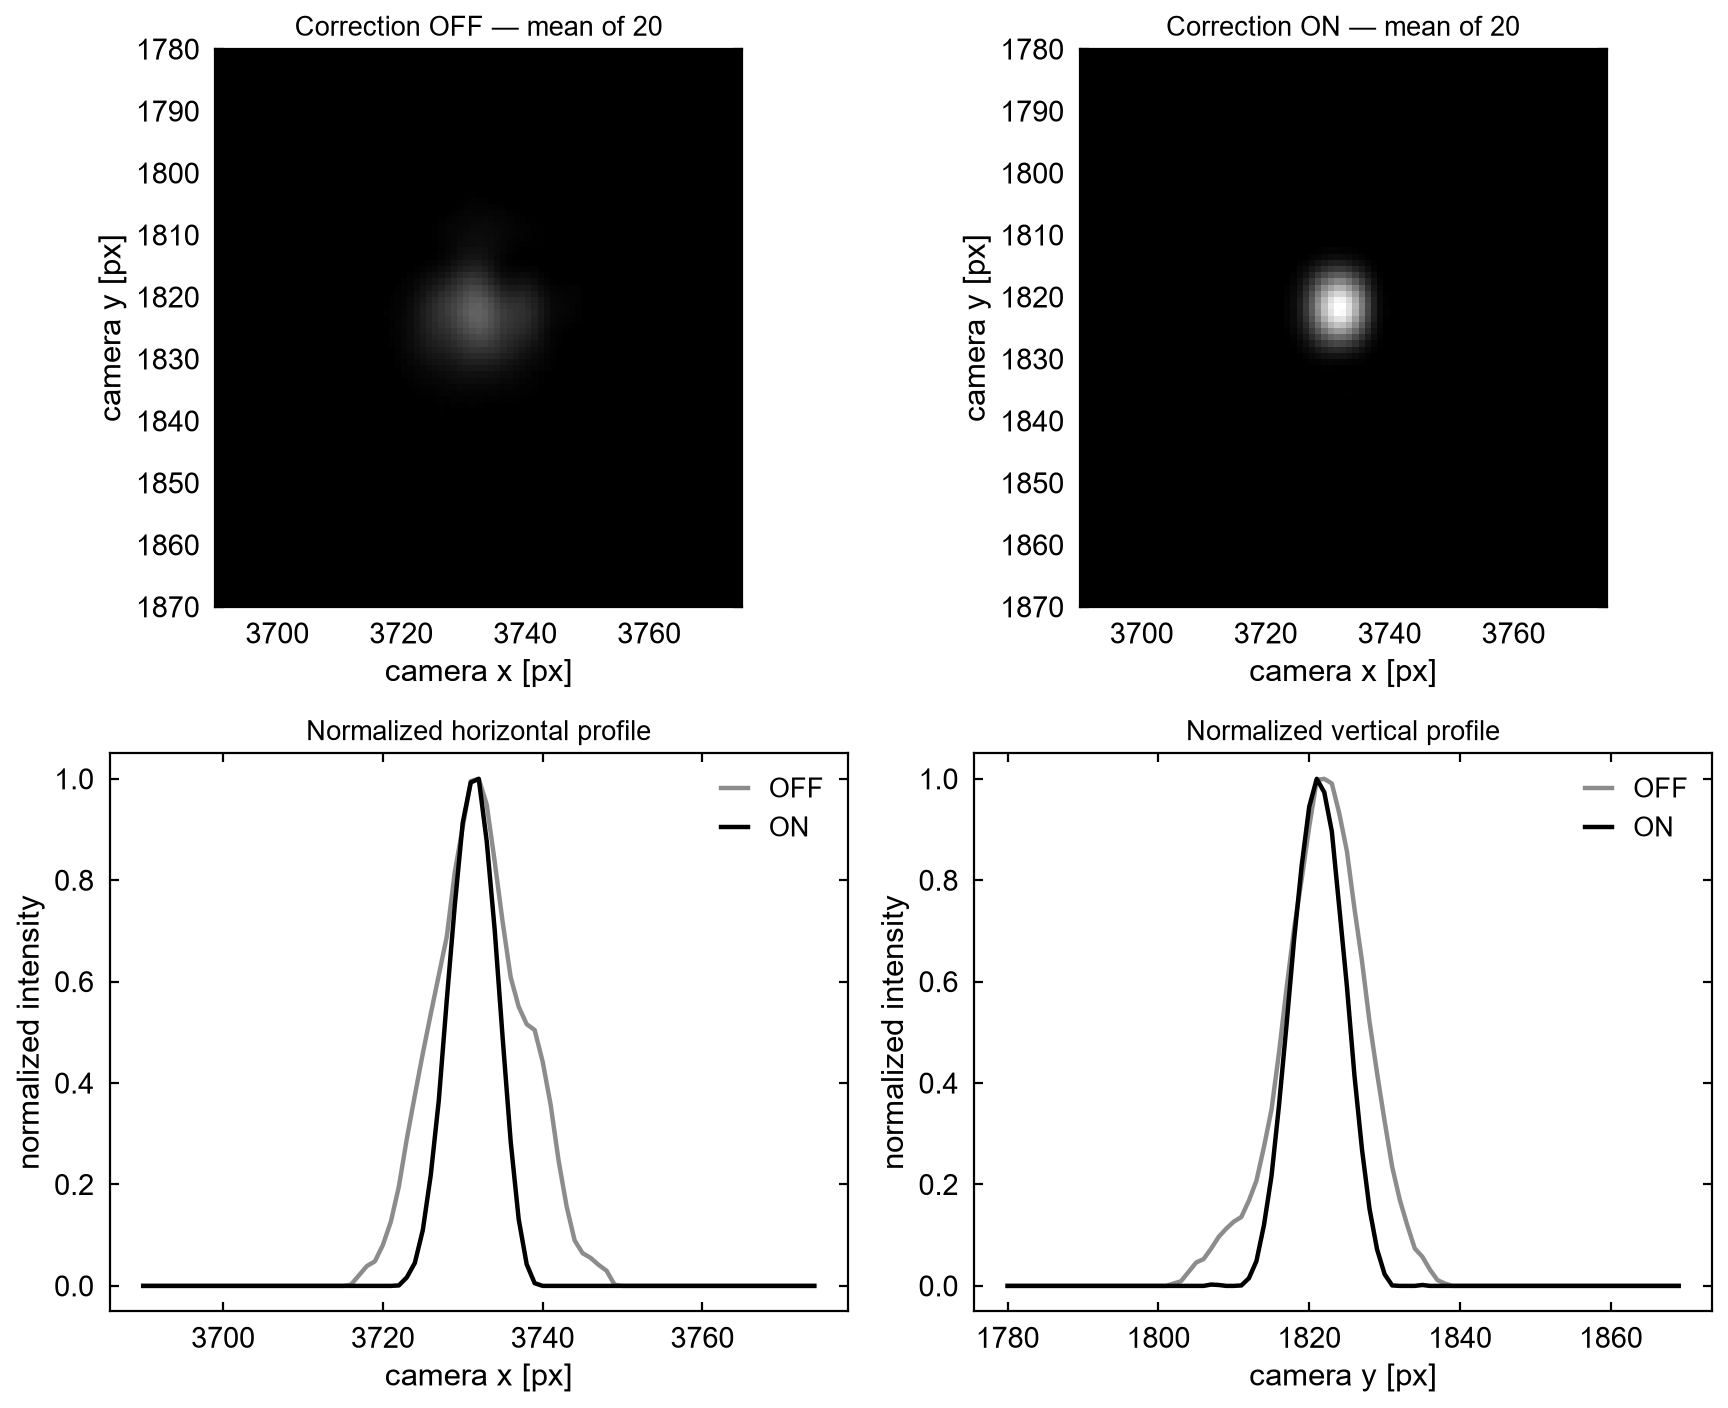


Saved:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\wavefront_validation_20260904_111022\01_fullSLM_16pixel_blaze_OFF_vs_ON.png

All full-SLM blaze data saved successfully.


In [61]:
# ============================================================
# DATASET 1/3
# FULL-SLM 16-PIXEL BLAZE
# 20 paired measurements: correction OFF vs ON
# ============================================================
cam.set_exposure(30e-6)
N_REPEATS = 20

# Tight carrier ROI from our validated measurement
BLAZE_ROI = (3690, 3775, 1780, 1870)   # x0, x1, y0, y1

x0, x1, y0, y1 = BLAZE_ROI

print("Experiment: Full-SLM 16-pixel blaze")
print("Repeats per state:", N_REPEATS)
print("Exposure [s]:", cam.exposure_s)
print("ROI:", BLAZE_ROI)
print()


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

records = []

roi_stack_off = []
roi_stack_on = []


# ------------------------------------------------------------
# Acquisition
# Alternate pair order to reduce drift/order bias.
# ------------------------------------------------------------

for rep in range(N_REPEATS):

    if rep % 2 == 0:
        states = [False, True]    # OFF -> ON
    else:
        states = [True, False]    # ON -> OFF

    print(
        f"Repeat {rep+1:02d}/{N_REPEATS} "
        f"order = {'OFF→ON' if rep % 2 == 0 else 'ON→OFF'}"
    )

    for phase_correct in states:

        state = "ON" if phase_correct else "OFF"

        roi = acquire_roi(
            phase_blaze_16,
            phase_correct=phase_correct,
            roi=BLAZE_ROI
        )

        fit = fit_single_spot(roi)

        # Convert fitted local centroid into full-camera coordinates
        x_cam = fit["x0"] + x0 if np.isfinite(fit["x0"]) else np.nan
        y_cam = fit["y0"] + y0 if np.isfinite(fit["y0"]) else np.nan

        # Useful concentration / effective-area metrics
        concentration = (
            fit["fit_peak"] / fit["total_counts"]
            if fit["total_counts"] > 0
            else np.nan
        )

        gaussian_area_px2 = (
            2 * np.pi *
            fit["sigma_x_px"] *
            fit["sigma_y_px"]
            if fit["fit_success"]
            else np.nan
        )

        records.append({
            "repeat": rep + 1,
            "state": state,

            "exposure_s": cam.exposure_s,

            "fit_success": fit["fit_success"],
            "saturated": fit["saturated"],

            "raw_peak": fit["raw_peak"],
            "fit_peak": fit["fit_peak"],
            "background": fit["background"],
            "total_counts": fit["total_counts"],

            "centroid_x_cam_px": x_cam,
            "centroid_y_cam_px": y_cam,

            "sigma_x_px": fit["sigma_x_px"],
            "sigma_y_px": fit["sigma_y_px"],

            "fwhm_x_px": fit["fwhm_x_px"],
            "fwhm_y_px": fit["fwhm_y_px"],

            "fwhm_x_um": fit["fwhm_x_um"],
            "fwhm_y_um": fit["fwhm_y_um"],

            "ellipticity": fit["ellipticity"],

            "gaussian_area_px2": gaussian_area_px2,
            "peak_per_total": concentration,
        })

        if phase_correct:
            roi_stack_on.append(roi)
        else:
            roi_stack_off.append(roi)


# ------------------------------------------------------------
# Convert to arrays / DataFrame
# ------------------------------------------------------------

df_blaze = pd.DataFrame(records)

roi_stack_off = np.stack(roi_stack_off)
roi_stack_on  = np.stack(roi_stack_on)

df_off = df_blaze[df_blaze["state"] == "OFF"].sort_values("repeat")
df_on  = df_blaze[df_blaze["state"] == "ON"].sort_values("repeat")


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

metrics = [
    "raw_peak",
    "fit_peak",
    "total_counts",
    "sigma_x_px",
    "sigma_y_px",
    "fwhm_x_px",
    "fwhm_y_px",
    "fwhm_x_um",
    "fwhm_y_um",
    "ellipticity",
    "gaussian_area_px2",
    "peak_per_total",
    "centroid_x_cam_px",
    "centroid_y_cam_px",
]

summary_rows = []

for state, d in [("OFF", df_off), ("ON", df_on)]:

    for metric in metrics:

        s = metric_stats(d[metric].values)

        summary_rows.append({
            "state": state,
            "metric": metric,
            **s
        })

df_summary_blaze = pd.DataFrame(summary_rows)


# ------------------------------------------------------------
# Paired ON/OFF ratios
# ------------------------------------------------------------

paired_metrics = [
    "raw_peak",
    "fit_peak",
    "total_counts",
    "sigma_x_px",
    "sigma_y_px",
    "fwhm_x_px",
    "fwhm_y_px",
    "ellipticity",
    "gaussian_area_px2",
    "peak_per_total",
]

ratio_rows = []

print("\n" + "="*65)
print("PAIRED ON / OFF RESULTS")
print("="*65)

for metric in paired_metrics:

    off_values = df_off[metric].to_numpy(dtype=float)
    on_values  = df_on[metric].to_numpy(dtype=float)

    ratio = on_values / off_values

    ratio_rows.append({
        "metric": metric,
        "mean_ratio": np.nanmean(ratio),
        "std_ratio": np.nanstd(ratio, ddof=1),
        "median_ratio": np.nanmedian(ratio),
        "q25_ratio": np.nanpercentile(ratio, 25),
        "q75_ratio": np.nanpercentile(ratio, 75),
    })

    print(
        f"{metric:20s}  "
        f"median={np.nanmedian(ratio):7.4f}   "
        f"mean={np.nanmean(ratio):7.4f} ± "
        f"{np.nanstd(ratio, ddof=1):7.4f}"
    )

df_ratios_blaze = pd.DataFrame(ratio_rows)


# ------------------------------------------------------------
# Compact wiki-style headline results
# ------------------------------------------------------------

print("\n" + "="*65)
print("WIKI SUMMARY — FULL-SLM 16-PIXEL BLAZE")
print("="*65)

for metric in [
    "fit_peak",
    "total_counts",
    "fwhm_x_px",
    "fwhm_y_px",
    "ellipticity"
]:

    off_vals = df_off[metric].to_numpy(dtype=float)
    on_vals  = df_on[metric].to_numpy(dtype=float)

    print(f"\n{metric}")
    print(
        " OFF:",
        f"{np.nanmean(off_vals):.4f} ± "
        f"{np.nanstd(off_vals, ddof=1):.4f}"
    )
    print(
        " ON :",
        f"{np.nanmean(on_vals):.4f} ± "
        f"{np.nanstd(on_vals, ddof=1):.4f}"
    )
    print(
        " median ON/OFF:",
        f"{np.nanmedian(on_vals/off_vals):.4f}"
    )


# ------------------------------------------------------------
# Saturation / fitting sanity checks
# ------------------------------------------------------------

print("\n" + "="*65)
print("QUALITY CHECK")
print("="*65)

print(
    "OFF saturated frames:",
    int(df_off["saturated"].sum()),
    "/",
    len(df_off)
)

print(
    "ON saturated frames :",
    int(df_on["saturated"].sum()),
    "/",
    len(df_on)
)

print(
    "OFF successful fits :",
    int(df_off["fit_success"].sum()),
    "/",
    len(df_off)
)

print(
    "ON successful fits  :",
    int(df_on["fit_success"].sum()),
    "/",
    len(df_on)
)


# ------------------------------------------------------------
# Mean images
# ------------------------------------------------------------

mean_off = roi_stack_off.mean(axis=0)
mean_on  = roi_stack_on.mean(axis=0)

vmax = max(mean_off.max(), mean_on.max())


# ------------------------------------------------------------
# WIKI FIGURE — grayscale only
# ------------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(11, 9))

axs[0,0].imshow(
    mean_off,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[0,0].set_title(
    f"Correction OFF — mean of {N_REPEATS}"
)

axs[0,1].imshow(
    mean_on,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[0,1].set_title(
    f"Correction ON — mean of {N_REPEATS}"
)

for ax in axs[0]:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")


# Horizontal profile through each mean-image maximum

iy_off, ix_off = np.unravel_index(
    np.argmax(mean_off),
    mean_off.shape
)

iy_on, ix_on = np.unravel_index(
    np.argmax(mean_on),
    mean_on.shape
)

profile_x_off = mean_off[iy_off, :]
profile_x_on  = mean_on[iy_on, :]

profile_y_off = mean_off[:, ix_off]
profile_y_on  = mean_on[:, ix_on]


axs[1,0].plot(
    np.arange(x0, x1),
    profile_x_off / profile_x_off.max(),
    color="0.55",
    linewidth=2,
    label="OFF"
)

axs[1,0].plot(
    np.arange(x0, x1),
    profile_x_on / profile_x_on.max(),
    color="black",
    linewidth=2,
    label="ON"
)

axs[1,0].set_title("Normalized horizontal profile")
axs[1,0].set_xlabel("camera x [px]")
axs[1,0].set_ylabel("normalized intensity")
axs[1,0].legend()


axs[1,1].plot(
    np.arange(y0, y1),
    profile_y_off / profile_y_off.max(),
    color="0.55",
    linewidth=2,
    label="OFF"
)

axs[1,1].plot(
    np.arange(y0, y1),
    profile_y_on / profile_y_on.max(),
    color="black",
    linewidth=2,
    label="ON"
)

axs[1,1].set_title("Normalized vertical profile")
axs[1,1].set_xlabel("camera y [px]")
axs[1,1].set_ylabel("normalized intensity")
axs[1,1].legend()

plt.tight_layout()


# ------------------------------------------------------------
# SAVE EVERYTHING
# ------------------------------------------------------------

figure_path = (
    VALIDATION_DIR /
    "01_fullSLM_16pixel_blaze_OFF_vs_ON.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


df_blaze.to_csv(
    VALIDATION_DIR /
    "01_fullSLM_16pixel_blaze_measurements.csv",
    index=False
)

df_summary_blaze.to_csv(
    VALIDATION_DIR /
    "01_fullSLM_16pixel_blaze_summary.csv",
    index=False
)

df_ratios_blaze.to_csv(
    VALIDATION_DIR /
    "01_fullSLM_16pixel_blaze_paired_ratios.csv",
    index=False
)

np.savez_compressed(
    VALIDATION_DIR /
    "01_fullSLM_16pixel_blaze_raw_ROIs.npz",

    roi_off=roi_stack_off,
    roi_on=roi_stack_on,

    roi=np.array(BLAZE_ROI),
    exposure_s=cam.exposure_s,
)

np.save(
    VALIDATION_DIR /
    "01_fullSLM_16pixel_blaze_phase.npy",
    phase_blaze_16
)


print("\nSaved:")
print(figure_path)
print("\nAll full-SLM blaze data saved successfully.")

Actual exposure [us]: 29.681
ROI max pixel value  : 188
Pixels >= 250        : 0
Pixels == 255        : 0
ROI mean             : 1.6562091503267973


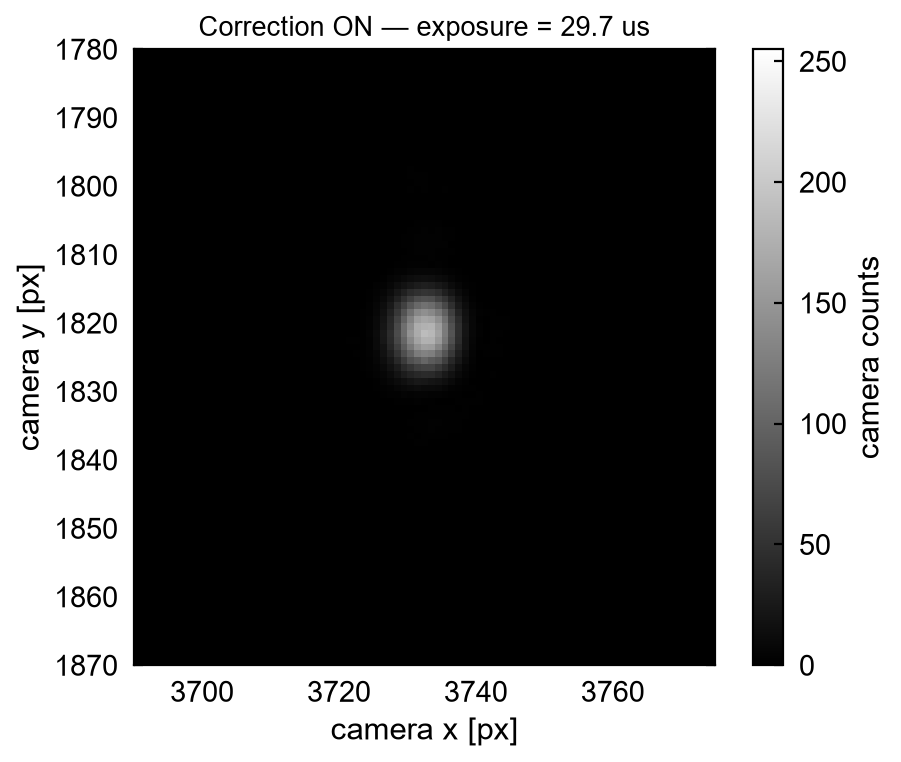

In [60]:
# ============================================================
# SIMPLE SATURATION CHECK — correction ON
# Change EXPOSURE_US manually and rerun
# ============================================================

EXPOSURE_US = 30   # <-- change this manually

# Carrier ROI
x0, x1 = 3690, 3775
y0, y1 = 1780, 1870

# Set exposure
cam.set_exposure(EXPOSURE_US * 1e-6)

# Display 16-pixel blaze with wavefront correction ON
slm.set_phase(
    phase_blaze_16,
    phase_correct=True,
    settle=True
)

cam.flush()
img = cam.get_image()

roi = img[y0:y1, x0:x1]

print("Actual exposure [us]:", cam.exposure_s * 1e6)
print("ROI max pixel value  :", roi.max())
print("Pixels >= 250        :", np.sum(roi >= 250))
print("Pixels == 255        :", np.sum(roi == 255))
print("ROI mean             :", roi.mean())

plt.figure(figsize=(6, 5))
plt.imshow(
    roi,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=255
)
plt.colorbar(label="camera counts")
plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title(
    f"Correction ON — exposure = {cam.exposure_s*1e6:.1f} us"
)
plt.show()

Actual exposure [us]: 497.181

5×5 corrected-array peak statistics
-------------------------------------
Number of spots used : 23
Maximum spot peak    : 141.0
Median spot peak     : 105.0
Mean spot peak       : 106.43478260869566
Minimum spot peak    : 85.0
Std spot peak        : 13.56742786287177

Uniformity
-------------------------------------
Peak CV [%]          : 12.747174871162203

Saturation
-------------------------------------
ROI max              : 141.0
Pixels >= 250        : 0
Pixels == 255        : 0
Spots >= 220         : 0
Spots >= 250         : 0

GOOD RANGE for the final 5×5 dataset.


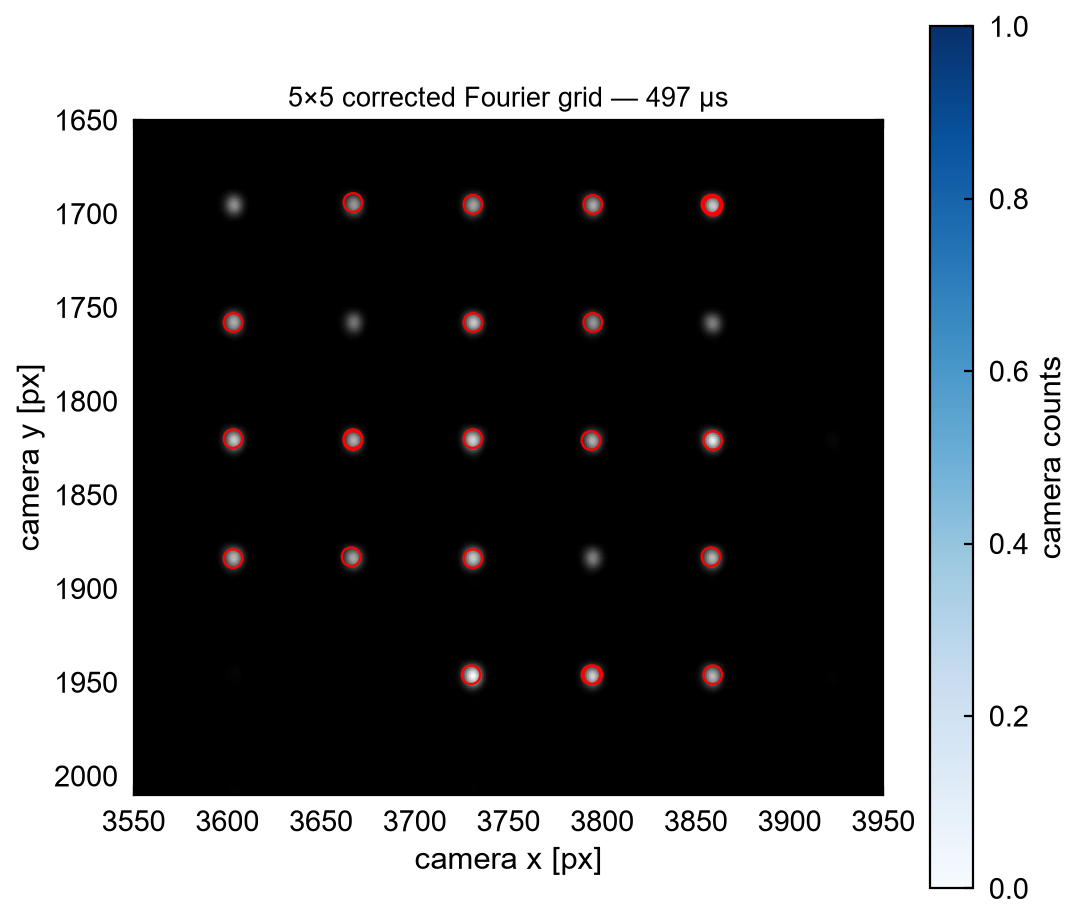

In [65]:
# ============================================================
# 5×5 LASER-POWER SCOUT — WAVEFRONT CORRECTION ON
#
# Manually change laser power, then rerun this cell.
# Keep EXPOSURE_US fixed while tuning laser power.
# ============================================================

EXPOSURE_US = 500       # start here; keep fixed while tuning power

# 5x5 ROI
x0, x1 = 3550, 3950
y0, y1 = 1650, 2010

cam.set_exposure(EXPOSURE_US * 1e-6)

# Display EXACT same 5x5 hologram with wavefront correction ON
slm.set_phase(
    phase_5x5,
    phase_correct=True,
    settle=True
)

cam.flush()
img = cam.get_image()

roi = img[y0:y1, x0:x1].astype(float)


# ------------------------------------------------------------
# Find the 23 calibration spots
# ------------------------------------------------------------

local_max = roi == maximum_filter(
    roi,
    size=35
)

coords = np.argwhere(local_max)

values = roi[
    coords[:, 0],
    coords[:, 1]
]

order = np.argsort(values)[::-1]

coords = coords[order[:23]]

spot_peaks = roi[
    coords[:, 0],
    coords[:, 1]
]


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("Actual exposure [us]:", cam.exposure_s * 1e6)

print("\n5×5 corrected-array peak statistics")
print("-------------------------------------")
print("Number of spots used :", len(spot_peaks))
print("Maximum spot peak    :", np.max(spot_peaks))
print("Median spot peak     :", np.median(spot_peaks))
print("Mean spot peak       :", np.mean(spot_peaks))
print("Minimum spot peak    :", np.min(spot_peaks))
print("Std spot peak        :", np.std(spot_peaks, ddof=1))

print("\nUniformity")
print("-------------------------------------")
print(
    "Peak CV [%]          :",
    100 * np.std(spot_peaks, ddof=1) / np.mean(spot_peaks)
)

print("\nSaturation")
print("-------------------------------------")
print("ROI max              :", roi.max())
print("Pixels >= 250        :", np.sum(roi >= 250))
print("Pixels == 255        :", np.sum(roi == 255))
print("Spots >= 220         :", np.sum(spot_peaks >= 220))
print("Spots >= 250         :", np.sum(spot_peaks >= 250))


# ------------------------------------------------------------
# Simple recommendation
# ------------------------------------------------------------

if np.max(spot_peaks) >= 240:
    print("\nTOO HIGH — reduce laser power.")

elif np.max(spot_peaks) > 200:
    print("\nA little high — reduce laser power slightly.")

elif np.median(spot_peaks) < 50:
    print("\nRather dim — increase laser power.")

else:
    print("\nGOOD RANGE for the final 5×5 dataset.")


# ------------------------------------------------------------
# Plot — black & white
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    roi,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=max(1, np.max(spot_peaks))
)

plt.scatter(
    coords[:, 1] + x0,
    coords[:, 0] + y0,
    facecolors="none",
    edgecolors="red",
    s=70
)

plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title(
    f"5×5 corrected Fourier grid — {cam.exposure_s*1e6:.0f} µs"
)

plt.colorbar(label="camera counts")
plt.tight_layout()
plt.show()

Experiment: 5×5 Fourier grid
Expected spots: 23
Repeats per state: 20
Exposure [us]: 497.181
ROI: (3550, 3950, 1650, 2010)

Repeat 01/20 order = OFF→ON
Repeat 02/20 order = ON→OFF
Repeat 03/20 order = OFF→ON
Repeat 04/20 order = ON→OFF
Repeat 05/20 order = OFF→ON
Repeat 06/20 order = ON→OFF
Repeat 07/20 order = OFF→ON
Repeat 08/20 order = ON→OFF
Repeat 09/20 order = OFF→ON
Repeat 10/20 order = ON→OFF
Repeat 11/20 order = OFF→ON
Repeat 12/20 order = ON→OFF
Repeat 13/20 order = OFF→ON
Repeat 14/20 order = ON→OFF
Repeat 15/20 order = OFF→ON
Repeat 16/20 order = ON→OFF
Repeat 17/20 order = OFF→ON
Repeat 18/20 order = ON→OFF
Repeat 19/20 order = OFF→ON
Repeat 20/20 order = ON→OFF

Detected spots: 23

5×5 PAIRED ON / OFF — ALL SPOTS, ALL REPEATS
raw_peak             median= 2.4132   mean= 2.4115 ±  0.2790
fit_peak             median= 2.7703   mean= 2.7629 ±  0.3118
total_counts         median= 1.0869   mean= 1.0940 ±  0.0432
sigma_x_px           median= 0.7050   mean= 0.7067 ±  0.0455
sigma_

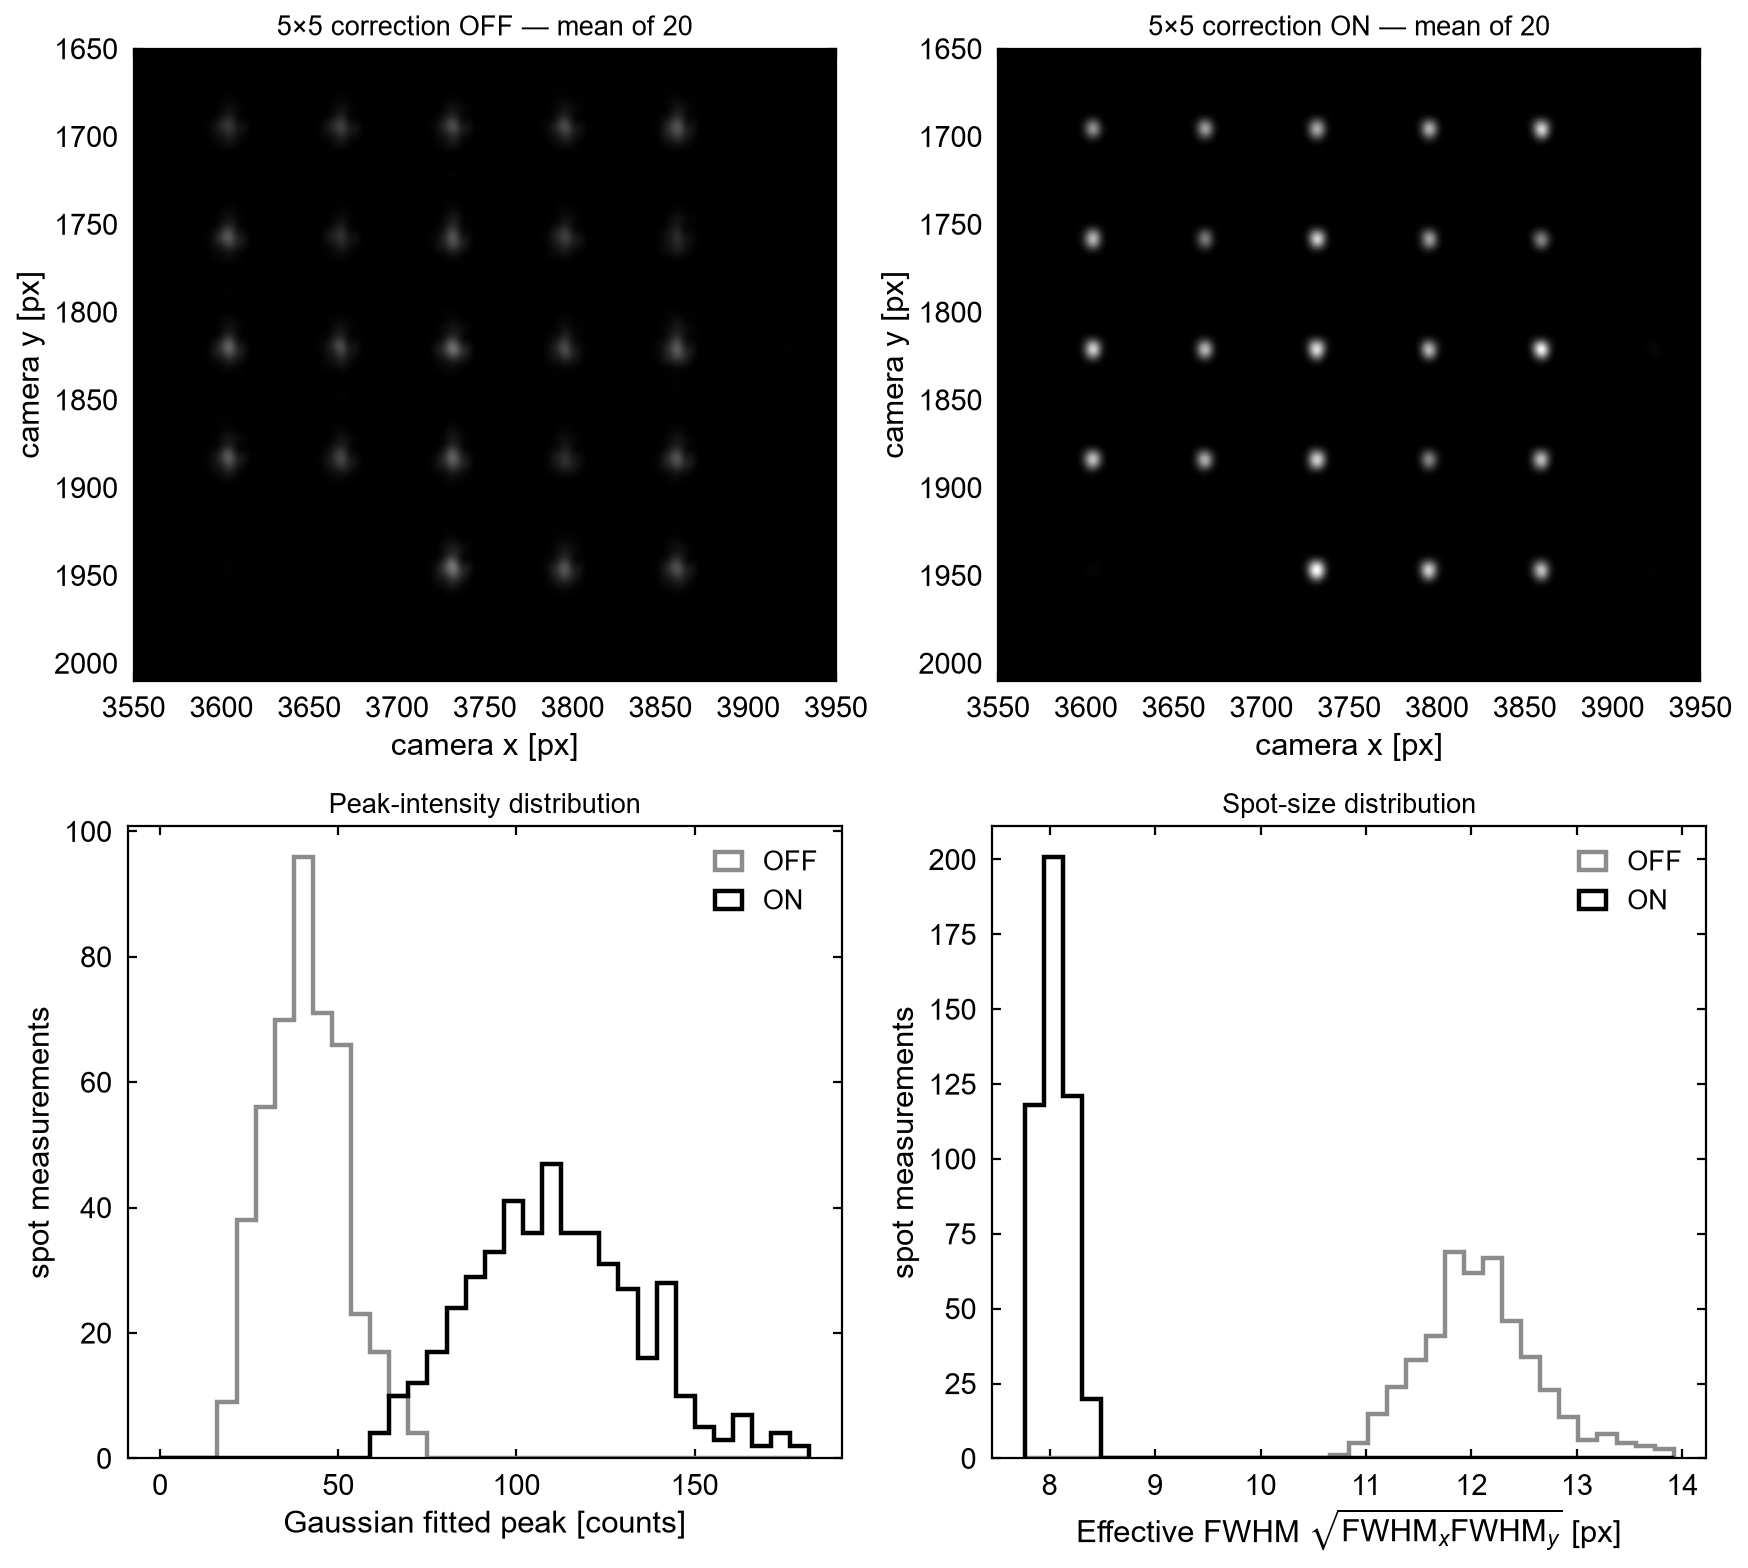


Saved figure:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\wavefront_validation_20260904_111022\02_5x5_Fourier_grid_OFF_vs_ON.png

All final 5×5 validation data saved.


In [66]:
# ============================================================
# DATASET 2/3 — FINAL
# 5×5 FOURIER GRID
# 20 paired measurements: wavefront correction OFF vs ON
#
# Same exact hologram phase in both states.
# 23 spots because orientation_check=True omits two corners.
# ============================================================

N_REPEATS = 20
EXPOSURE_US = 500

cam.set_exposure(EXPOSURE_US * 1e-6)

GRID5_ROI = (3550, 3950, 1650, 2010)   # x0, x1, y0, y1
x0, x1, y0, y1 = GRID5_ROI

PATCH_HALFBOX = 18

print("Experiment: 5×5 Fourier grid")
print("Expected spots:", 23)
print("Repeats per state:", N_REPEATS)
print("Exposure [us]:", cam.exposure_s * 1e6)
print("ROI:", GRID5_ROI)
print()


# ------------------------------------------------------------
# ACQUIRE FIRST
# Alternate OFF→ON / ON→OFF to suppress temporal bias
# ------------------------------------------------------------

roi_stack_off = []
roi_stack_on  = []

for rep in range(N_REPEATS):

    if rep % 2 == 0:
        states = [False, True]
    else:
        states = [True, False]

    print(
        f"Repeat {rep+1:02d}/{N_REPEATS} "
        f"order = {'OFF→ON' if rep % 2 == 0 else 'ON→OFF'}"
    )

    for phase_correct in states:

        roi = acquire_roi(
            phase_5x5,
            phase_correct=phase_correct,
            roi=GRID5_ROI
        )

        if phase_correct:
            roi_stack_on.append(roi)
        else:
            roi_stack_off.append(roi)


roi_stack_off = np.stack(roi_stack_off)
roi_stack_on  = np.stack(roi_stack_on)

mean_off = roi_stack_off.mean(axis=0)
mean_on  = roi_stack_on.mean(axis=0)


# ------------------------------------------------------------
# DETECT THE 23 SPOTS ON THE MEAN CORRECTED IMAGE
# ------------------------------------------------------------

coords = detect_spots(
    mean_on,
    nspots=23,
    neighborhood=35
)

print("\nDetected spots:", len(coords))


# ------------------------------------------------------------
# ANALYZE EVERY SPOT IN EVERY FRAME
# ------------------------------------------------------------

spot_records = []

for state, stack in [
    ("OFF", roi_stack_off),
    ("ON",  roi_stack_on)
]:

    for rep in range(N_REPEATS):

        frame = stack[rep]

        for spot_id, (yc, xc) in enumerate(coords):

            ya = max(0, yc - PATCH_HALFBOX)
            yb = min(frame.shape[0], yc + PATCH_HALFBOX + 1)

            xa = max(0, xc - PATCH_HALFBOX)
            xb = min(frame.shape[1], xc + PATCH_HALFBOX + 1)

            patch = frame[ya:yb, xa:xb]

            fit = fit_single_spot(patch)

            # Convert local fitted position to camera coordinates
            if fit["fit_success"]:

                x_cam = x0 + xa + fit["x0"]
                y_cam = y0 + ya + fit["y0"]

                gaussian_area = (
                    2 * np.pi *
                    fit["sigma_x_px"] *
                    fit["sigma_y_px"]
                )

                peak_per_total = (
                    fit["fit_peak"] / fit["total_counts"]
                    if fit["total_counts"] > 0
                    else np.nan
                )

            else:

                x_cam = np.nan
                y_cam = np.nan
                gaussian_area = np.nan
                peak_per_total = np.nan

            spot_records.append({

                "repeat": rep + 1,
                "state": state,
                "spot_id": spot_id,

                "exposure_s": cam.exposure_s,

                "fit_success": fit["fit_success"],
                "saturated": fit["saturated"],

                "raw_peak": fit["raw_peak"],
                "fit_peak": fit["fit_peak"],
                "background": fit["background"],
                "total_counts": fit["total_counts"],

                "centroid_x_cam_px": x_cam,
                "centroid_y_cam_px": y_cam,

                "sigma_x_px": fit["sigma_x_px"],
                "sigma_y_px": fit["sigma_y_px"],

                "fwhm_x_px": fit["fwhm_x_px"],
                "fwhm_y_px": fit["fwhm_y_px"],

                "fwhm_x_um": fit["fwhm_x_um"],
                "fwhm_y_um": fit["fwhm_y_um"],

                "ellipticity": fit["ellipticity"],

                "gaussian_area_px2": gaussian_area,
                "peak_per_total": peak_per_total,
            })


df_5x5 = pd.DataFrame(spot_records)


# ------------------------------------------------------------
# FRAME-BY-FRAME ARRAY STATISTICS
# Useful for uniformity/stability
# ------------------------------------------------------------

frame_records = []

for state in ["OFF", "ON"]:

    dstate = df_5x5[df_5x5["state"] == state]

    for rep in range(1, N_REPEATS + 1):

        d = dstate[dstate["repeat"] == rep]

        peaks = d["fit_peak"].to_numpy(float)
        powers = d["total_counts"].to_numpy(float)

        frame_records.append({

            "state": state,
            "repeat": rep,

            "median_fit_peak": np.nanmedian(peaks),
            "mean_fit_peak": np.nanmean(peaks),

            "peak_cv_percent":
                100 * np.nanstd(peaks, ddof=1) / np.nanmean(peaks),

            "median_total_counts":
                np.nanmedian(powers),

            "power_cv_percent":
                100 * np.nanstd(powers, ddof=1) / np.nanmean(powers),

            "median_fwhm_x_px":
                np.nanmedian(d["fwhm_x_px"]),

            "median_fwhm_y_px":
                np.nanmedian(d["fwhm_y_px"]),

            "median_ellipticity":
                np.nanmedian(d["ellipticity"]),

            "successful_fits":
                int(d["fit_success"].sum()),

            "saturated_spots":
                int(d["saturated"].sum()),
        })


df_5x5_frames = pd.DataFrame(frame_records)


# ------------------------------------------------------------
# PER-SPOT PAIRED ON/OFF RATIOS
#
# Each spot in each repeat is compared against itself.
# Gives 23 × 20 = 460 paired measurements.
# ------------------------------------------------------------

off = (
    df_5x5[df_5x5["state"] == "OFF"]
    .sort_values(["repeat", "spot_id"])
    .reset_index(drop=True)
)

on = (
    df_5x5[df_5x5["state"] == "ON"]
    .sort_values(["repeat", "spot_id"])
    .reset_index(drop=True)
)


ratio_metrics = [
    "raw_peak",
    "fit_peak",
    "total_counts",
    "sigma_x_px",
    "sigma_y_px",
    "fwhm_x_px",
    "fwhm_y_px",
    "ellipticity",
    "gaussian_area_px2",
    "peak_per_total",
]

ratio_rows = []

print("\n" + "="*72)
print("5×5 PAIRED ON / OFF — ALL SPOTS, ALL REPEATS")
print("="*72)

for metric in ratio_metrics:

    ratio = (
        on[metric].to_numpy(float) /
        off[metric].to_numpy(float)
    )

    ratio_rows.append({

        "metric": metric,

        "N": np.sum(np.isfinite(ratio)),

        "mean_ratio": np.nanmean(ratio),
        "std_ratio": np.nanstd(ratio, ddof=1),

        "median_ratio": np.nanmedian(ratio),

        "q25_ratio": np.nanpercentile(ratio, 25),
        "q75_ratio": np.nanpercentile(ratio, 75),
    })

    print(
        f"{metric:20s} "
        f"median={np.nanmedian(ratio):7.4f}   "
        f"mean={np.nanmean(ratio):7.4f} ± "
        f"{np.nanstd(ratio, ddof=1):7.4f}"
    )


df_5x5_ratios = pd.DataFrame(ratio_rows)


# ------------------------------------------------------------
# GLOBAL SUMMARY
# ------------------------------------------------------------

summary_metrics = [
    "fit_peak",
    "total_counts",

    "sigma_x_px",
    "sigma_y_px",

    "fwhm_x_px",
    "fwhm_y_px",

    "fwhm_x_um",
    "fwhm_y_um",

    "ellipticity",

    "gaussian_area_px2",
    "peak_per_total",
]

summary_rows = []

for state in ["OFF", "ON"]:

    d = df_5x5[df_5x5["state"] == state]

    for metric in summary_metrics:

        values = d[metric].to_numpy(float)
        values = values[np.isfinite(values)]

        summary_rows.append({

            "state": state,
            "metric": metric,

            "N": len(values),

            "mean": np.mean(values),
            "std": np.std(values, ddof=1),

            "median": np.median(values),

            "q25": np.percentile(values, 25),
            "q75": np.percentile(values, 75),
        })


df_5x5_summary = pd.DataFrame(summary_rows)


# ------------------------------------------------------------
# WIKI HEADLINE NUMBERS
# ------------------------------------------------------------

print("\n" + "="*72)
print("WIKI SUMMARY — 5×5 FOURIER GRID")
print("="*72)

for metric in [
    "fit_peak",
    "total_counts",
    "fwhm_x_px",
    "fwhm_y_px",
    "ellipticity",
]:

    a = off[metric].to_numpy(float)
    b = on[metric].to_numpy(float)

    print(f"\n{metric}")

    print(
        f" OFF: {np.nanmean(a):.4f} ± "
        f"{np.nanstd(a, ddof=1):.4f}"
    )

    print(
        f" ON : {np.nanmean(b):.4f} ± "
        f"{np.nanstd(b, ddof=1):.4f}"
    )

    print(
        f" median ON/OFF: "
        f"{np.nanmedian(b/a):.4f}"
    )


# ------------------------------------------------------------
# ARRAY UNIFORMITY
# Average frame-level statistics
# ------------------------------------------------------------

print("\n" + "="*72)
print("ARRAY UNIFORMITY / STABILITY")
print("="*72)

for state in ["OFF", "ON"]:

    d = df_5x5_frames[
        df_5x5_frames["state"] == state
    ]

    print(f"\n{state}")

    print(
        "Peak CV [%]  :",
        f"{d['peak_cv_percent'].mean():.2f} ± "
        f"{d['peak_cv_percent'].std(ddof=1):.2f}"
    )

    print(
        "Power CV [%] :",
        f"{d['power_cv_percent'].mean():.2f} ± "
        f"{d['power_cv_percent'].std(ddof=1):.2f}"
    )

    print(
        "Median FWHMx :",
        f"{d['median_fwhm_x_px'].mean():.3f} px"
    )

    print(
        "Median FWHMy :",
        f"{d['median_fwhm_y_px'].mean():.3f} px"
    )


# ------------------------------------------------------------
# QUALITY CHECK
# ------------------------------------------------------------

print("\n" + "="*72)
print("QUALITY CHECK")
print("="*72)

for state in ["OFF", "ON"]:

    d = df_5x5[df_5x5["state"] == state]

    print(
        f"{state}: "
        f"{int(d['fit_success'].sum())}/{len(d)} successful fits, "
        f"{int(d['saturated'].sum())} saturated spot measurements"
    )


# ------------------------------------------------------------
# WIKI FIGURE — BLACK / WHITE / GRAYSCALE
# ------------------------------------------------------------

vmax = max(mean_off.max(), mean_on.max())

fig, axs = plt.subplots(
    2, 2,
    figsize=(11, 10)
)

axs[0,0].imshow(
    mean_off,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[0,0].set_title(
    f"5×5 correction OFF — mean of {N_REPEATS}"
)

axs[0,1].imshow(
    mean_on,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[0,1].set_title(
    f"5×5 correction ON — mean of {N_REPEATS}"
)

for ax in axs[0]:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")


# ------------------------------------------------------------
# Distribution of fitted peaks
# ------------------------------------------------------------

bins_peak = np.linspace(
    0,
    max(
        df_5x5["fit_peak"].max(),
        1
    ),
    35
)

axs[1,0].hist(
    off["fit_peak"],
    bins=bins_peak,
    histtype="step",
    linewidth=2,
    color="0.55",
    label="OFF"
)

axs[1,0].hist(
    on["fit_peak"],
    bins=bins_peak,
    histtype="step",
    linewidth=2,
    color="black",
    label="ON"
)

axs[1,0].set_xlabel("Gaussian fitted peak [counts]")
axs[1,0].set_ylabel("spot measurements")
axs[1,0].set_title("Peak-intensity distribution")
axs[1,0].legend()


# ------------------------------------------------------------
# Distribution of effective Gaussian width
# ------------------------------------------------------------

width_off = np.sqrt(
    off["fwhm_x_px"] *
    off["fwhm_y_px"]
)

width_on = np.sqrt(
    on["fwhm_x_px"] *
    on["fwhm_y_px"]
)

bins_width = np.linspace(
    min(width_off.min(), width_on.min()),
    max(width_off.max(), width_on.max()),
    35
)

axs[1,1].hist(
    width_off,
    bins=bins_width,
    histtype="step",
    linewidth=2,
    color="0.55",
    label="OFF"
)

axs[1,1].hist(
    width_on,
    bins=bins_width,
    histtype="step",
    linewidth=2,
    color="black",
    label="ON"
)

axs[1,1].set_xlabel(
    r"Effective FWHM $\sqrt{\mathrm{FWHM}_x\mathrm{FWHM}_y}$ [px]"
)

axs[1,1].set_ylabel("spot measurements")
axs[1,1].set_title("Spot-size distribution")
axs[1,1].legend()

plt.tight_layout()


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

figure_path = (
    VALIDATION_DIR /
    "02_5x5_Fourier_grid_OFF_vs_ON.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


df_5x5.to_csv(
    VALIDATION_DIR /
    "02_5x5_Fourier_grid_spot_measurements.csv",
    index=False
)

df_5x5_frames.to_csv(
    VALIDATION_DIR /
    "02_5x5_Fourier_grid_frame_statistics.csv",
    index=False
)

df_5x5_summary.to_csv(
    VALIDATION_DIR /
    "02_5x5_Fourier_grid_summary.csv",
    index=False
)

df_5x5_ratios.to_csv(
    VALIDATION_DIR /
    "02_5x5_Fourier_grid_paired_ratios.csv",
    index=False
)

np.savez_compressed(
    VALIDATION_DIR /
    "02_5x5_Fourier_grid_raw_ROIs.npz",

    roi_off=roi_stack_off,
    roi_on=roi_stack_on,

    spot_coords_yx=coords,

    roi=np.array(GRID5_ROI),

    exposure_s=cam.exposure_s,
)

np.save(
    VALIDATION_DIR /
    "02_5x5_Fourier_grid_phase.npy",
    phase_5x5
)


print("\nSaved figure:")
print(figure_path)

print("\nAll final 5×5 validation data saved.")

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\toolbox\__init__.py:258: UserWarning: CameraSLM must be passed as slm for conversion 'kxy' to 'ij'
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

Actual exposure [us]: 2009.681

10×10 corrected-array peak statistics
--------------------------------------
Number of spots used : 98
Maximum spot peak    : 174.0
Median spot peak     : 102.0
Mean spot peak       : 104.83673469387755
Minimum spot peak    : 89.0
Std spot peak        : 13.54084609391881

Uniformity
--------------------------------------
Peak CV [%]          : 12.916127284446597

Saturation
--------------------------------------
ROI max              : 174.0
Pixels >= 250        : 0
Pixels == 255        : 0
Spots >= 220         : 0
Spots >= 250         : 0

GOOD RANGE for the final 10×10 dataset.


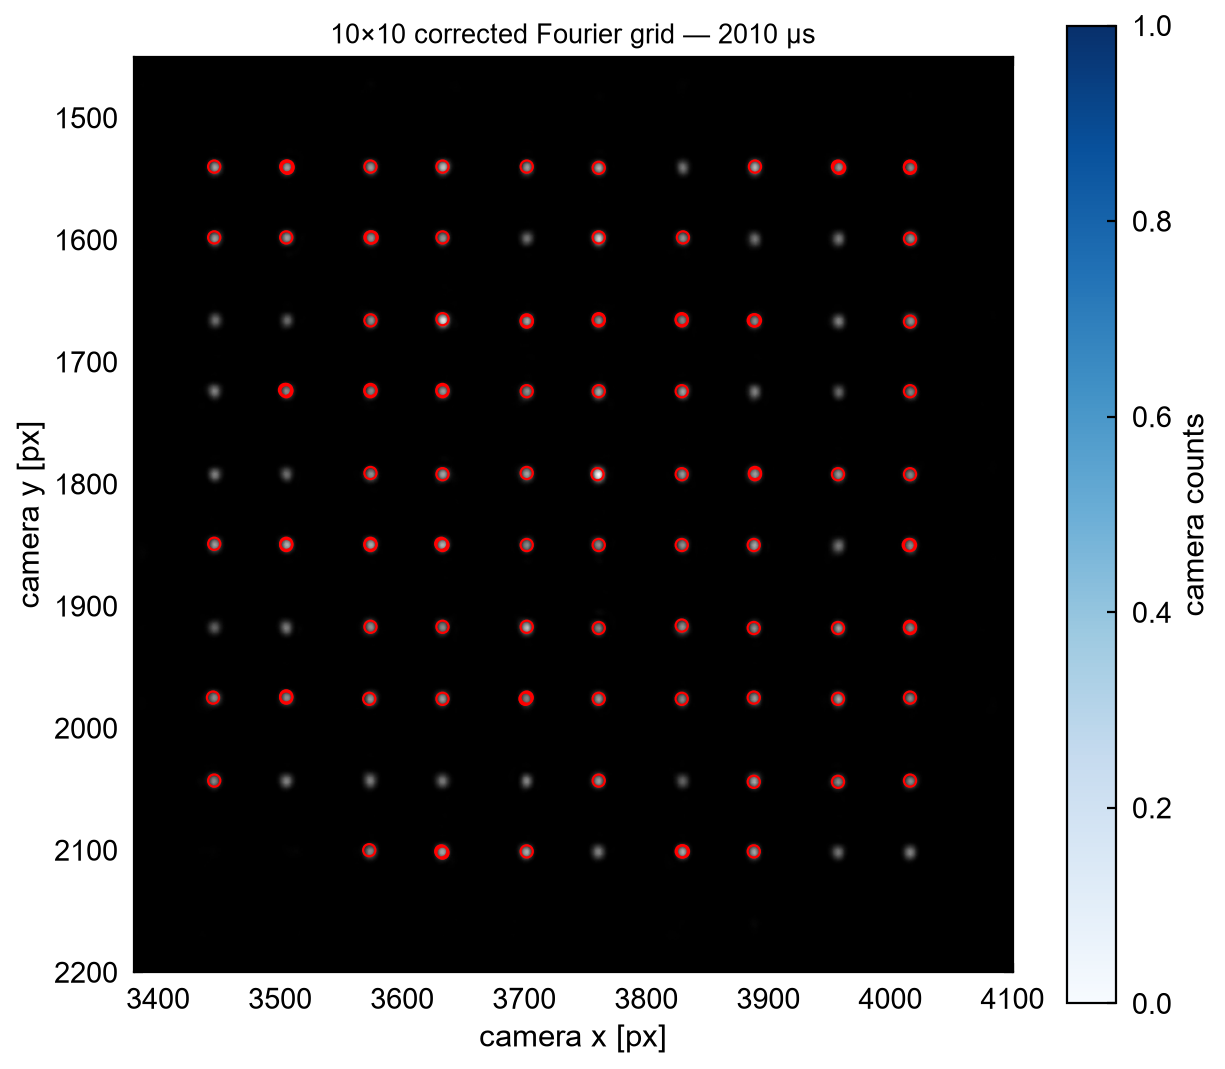

In [67]:
# ============================================================
# 10×10 LASER-POWER / EXPOSURE SCOUT
# WAVEFRONT CORRECTION ON
#
# Manually change EXPOSURE_US and/or laser power,
# then rerun this cell until the spot peaks are good.
# ============================================================

EXPOSURE_US = 2000      # start around 2 ms

# ------------------------------------------------------------
# Generate 10×10 Fourier calibration hologram
# Same pitch and carrier center as the 5×5
# ------------------------------------------------------------

holo_10x10 = fs.fourier_grid_project(
    array_shape=(10, 10),
    array_pitch=(13, 13),
    array_center=(128, 0),
    method="GS",
    maxiter=10,
)

phase_10x10 = holo_10x10.get_phase()


# ------------------------------------------------------------
# Display explicitly WITH wavefront correction
# ------------------------------------------------------------

cam.set_exposure(EXPOSURE_US * 1e-6)

slm.set_phase(
    phase_10x10,
    phase_correct=True,
    settle=True
)

cam.flush()
img = cam.get_image()


# ------------------------------------------------------------
# ROI containing the whole 10×10 grid
# ------------------------------------------------------------

x0, x1 = 3380, 4100
y0, y1 = 1450, 2200

roi = img[y0:y1, x0:x1].astype(float)


# ------------------------------------------------------------
# Detect expected 98 spots
# orientation_check=True removes two parity-check corners
# ------------------------------------------------------------

local_max = roi == maximum_filter(
    roi,
    size=35
)

coords = np.argwhere(local_max)

values = roi[
    coords[:, 0],
    coords[:, 1]
]

order = np.argsort(values)[::-1]

coords = coords[order[:98]]

spot_peaks = roi[
    coords[:, 0],
    coords[:, 1]
]


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("Actual exposure [us]:", cam.exposure_s * 1e6)

print("\n10×10 corrected-array peak statistics")
print("--------------------------------------")
print("Number of spots used :", len(spot_peaks))
print("Maximum spot peak    :", np.max(spot_peaks))
print("Median spot peak     :", np.median(spot_peaks))
print("Mean spot peak       :", np.mean(spot_peaks))
print("Minimum spot peak    :", np.min(spot_peaks))
print("Std spot peak        :", np.std(spot_peaks, ddof=1))

print("\nUniformity")
print("--------------------------------------")
print(
    "Peak CV [%]          :",
    100 * np.std(spot_peaks, ddof=1) / np.mean(spot_peaks)
)

print("\nSaturation")
print("--------------------------------------")
print("ROI max              :", roi.max())
print("Pixels >= 250        :", np.sum(roi >= 250))
print("Pixels == 255        :", np.sum(roi == 255))
print("Spots >= 220         :", np.sum(spot_peaks >= 220))
print("Spots >= 250         :", np.sum(spot_peaks >= 250))


# ------------------------------------------------------------
# Simple recommendation
# ------------------------------------------------------------

if np.max(spot_peaks) >= 240:
    print("\nTOO HIGH — reduce exposure or laser power.")

elif np.max(spot_peaks) > 200:
    print("\nA little high — reduce exposure slightly.")

elif np.median(spot_peaks) < 50:
    print("\nRather dim — increase exposure.")

else:
    print("\nGOOD RANGE for the final 10×10 dataset.")


# ------------------------------------------------------------
# Plot — grayscale
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

plt.imshow(
    roi,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=max(1, np.max(spot_peaks))
)

plt.scatter(
    coords[:, 1] + x0,
    coords[:, 0] + y0,
    facecolors="none",
    edgecolors="red",
    s=30
)

plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title(
    f"10×10 corrected Fourier grid — {cam.exposure_s*1e6:.0f} µs"
)

plt.colorbar(label="camera counts")
plt.tight_layout()
plt.show()

Experiment: 10×10 Fourier grid
Expected spots: 98
Repeats per state: 20
Exposure [us]: 2009.681
ROI: (3380, 4100, 1450, 2200)

Repeat 01/20 order = OFF→ON
Repeat 02/20 order = ON→OFF
Repeat 03/20 order = OFF→ON
Repeat 04/20 order = ON→OFF
Repeat 05/20 order = OFF→ON
Repeat 06/20 order = ON→OFF
Repeat 07/20 order = OFF→ON
Repeat 08/20 order = ON→OFF
Repeat 09/20 order = OFF→ON
Repeat 10/20 order = ON→OFF
Repeat 11/20 order = OFF→ON
Repeat 12/20 order = ON→OFF
Repeat 13/20 order = OFF→ON
Repeat 14/20 order = ON→OFF
Repeat 15/20 order = OFF→ON
Repeat 16/20 order = ON→OFF
Repeat 17/20 order = OFF→ON
Repeat 18/20 order = ON→OFF
Repeat 19/20 order = OFF→ON
Repeat 20/20 order = ON→OFF

Detected spots: 98

10×10 PAIRED ON / OFF — ALL SPOTS, ALL REPEATS
raw_peak             median= 2.2400   mean= 2.2569 ±  0.3105
fit_peak             median= 2.5651   mean= 2.5821 ±  0.3830
total_counts         median= 1.0759   mean= 1.0825 ±  0.0610
sigma_x_px           median= 0.7434   mean= 0.7450 ±  0.0702
s

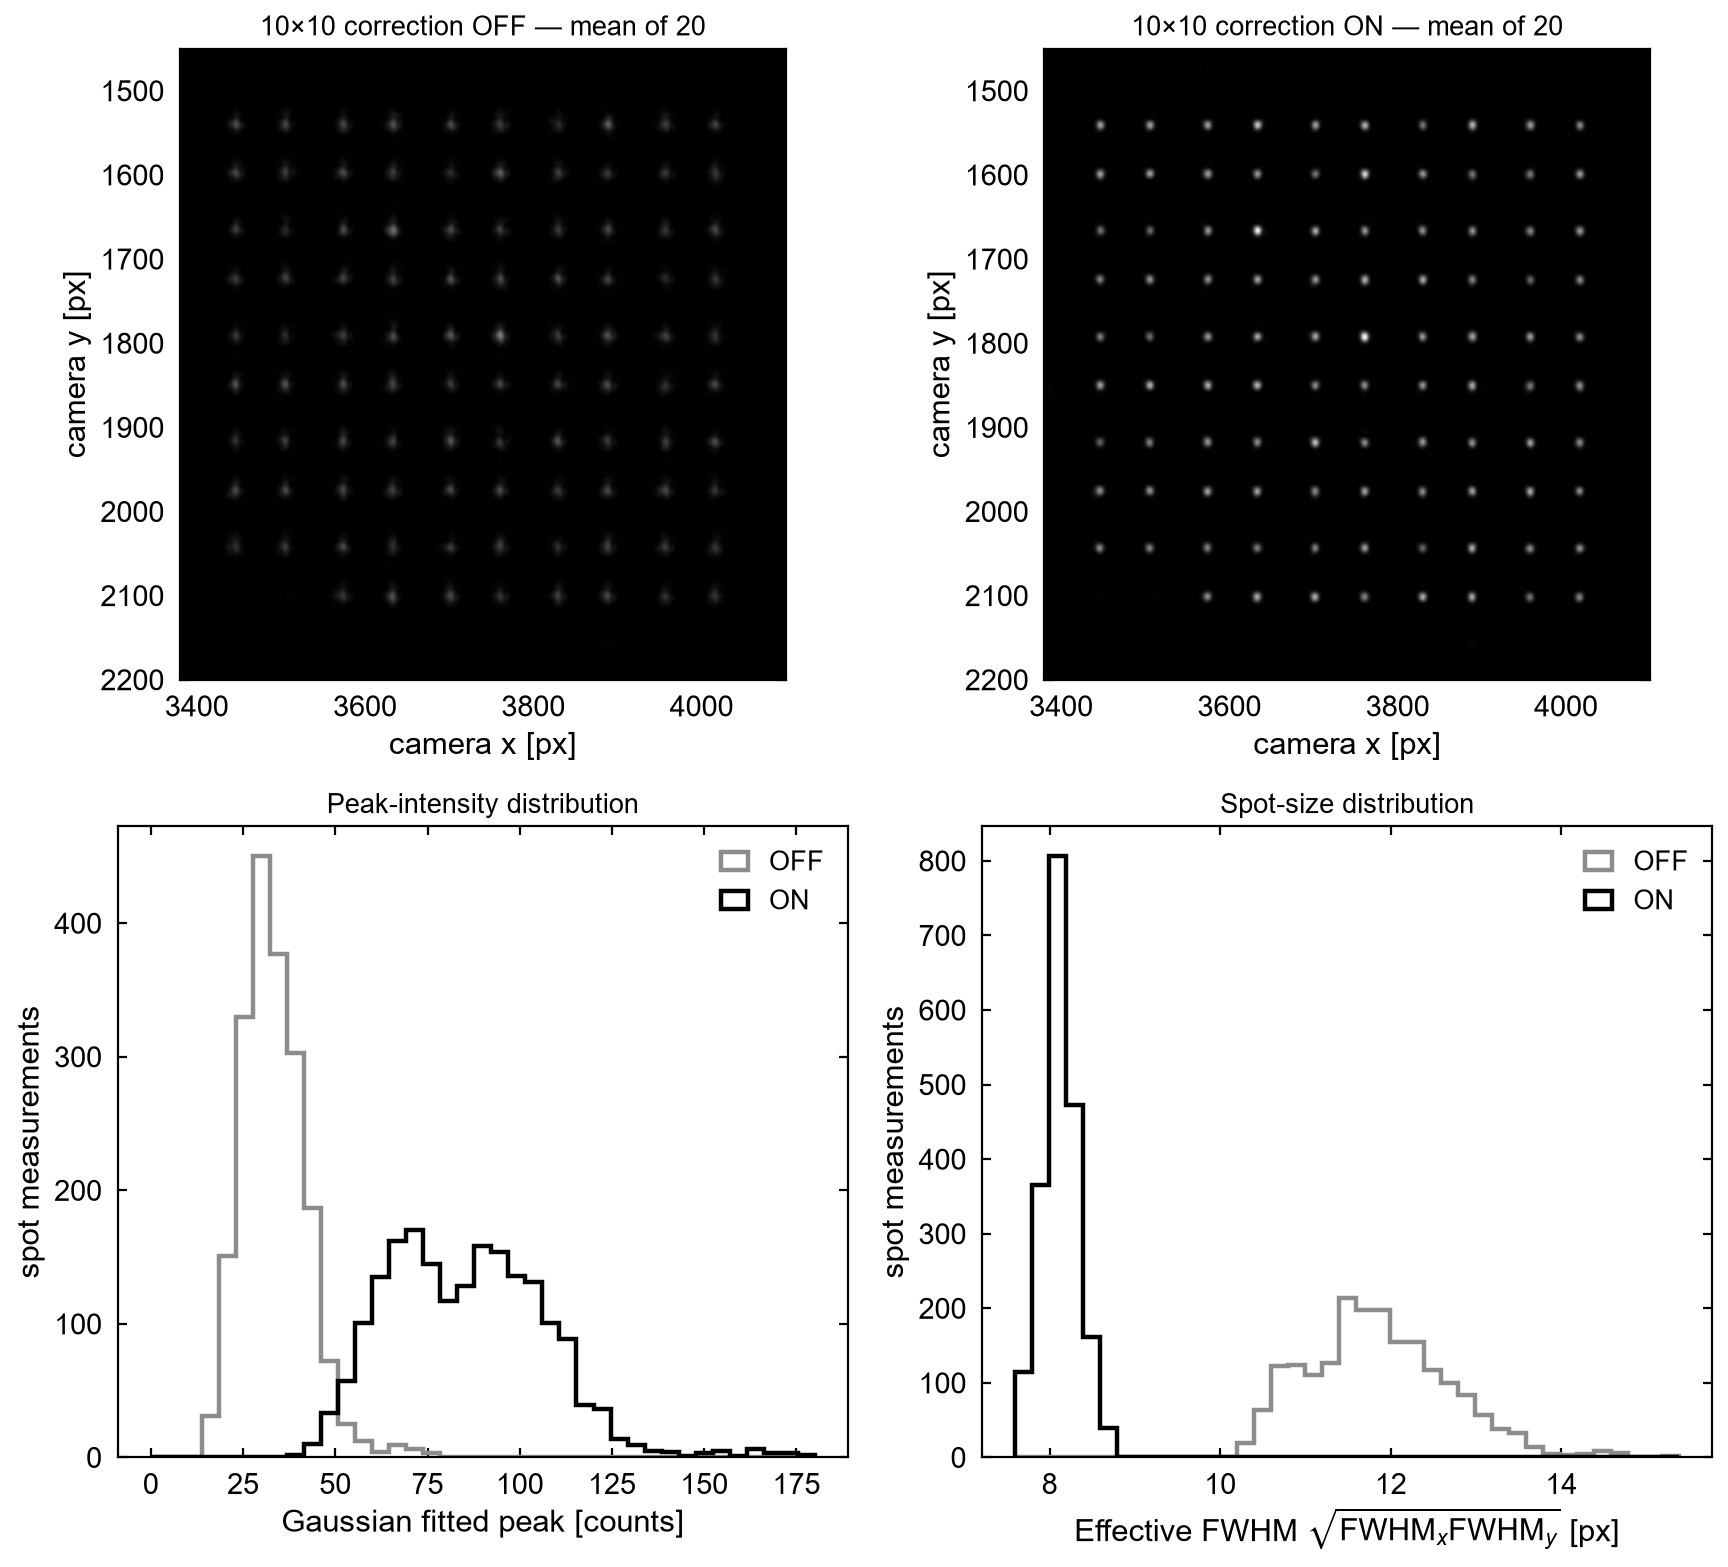


Saved figure:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\wavefront_validation_20260904_111022\03_10x10_Fourier_grid_OFF_vs_ON.png

All final 10×10 validation data saved.


In [68]:
# ============================================================
# DATASET 3/3 — FINAL
# 10×10 FOURIER GRID
# 20 paired measurements: wavefront correction OFF vs ON
#
# Same exact hologram phase in both states.
# 98 spots because orientation_check=True removes two corners.
# ============================================================

N_REPEATS = 20
EXPOSURE_US = 2000

cam.set_exposure(EXPOSURE_US * 1e-6)

GRID10_ROI = (3380, 4100, 1450, 2200)   # x0, x1, y0, y1
x0, x1, y0, y1 = GRID10_ROI

PATCH_HALFBOX = 18

print("Experiment: 10×10 Fourier grid")
print("Expected spots:", 98)
print("Repeats per state:", N_REPEATS)
print("Exposure [us]:", cam.exposure_s * 1e6)
print("ROI:", GRID10_ROI)
print()


# ============================================================
# 1. ACQUIRE 20 OFF/ON PAIRS
# ============================================================

roi_stack_off_10 = []
roi_stack_on_10  = []

for rep in range(N_REPEATS):

    if rep % 2 == 0:
        states = [False, True]     # OFF → ON
    else:
        states = [True, False]     # ON → OFF

    print(
        f"Repeat {rep+1:02d}/{N_REPEATS} "
        f"order = {'OFF→ON' if rep % 2 == 0 else 'ON→OFF'}"
    )

    for phase_correct in states:

        roi = acquire_roi(
            phase_10x10,
            phase_correct=phase_correct,
            roi=GRID10_ROI
        )

        if phase_correct:
            roi_stack_on_10.append(roi)
        else:
            roi_stack_off_10.append(roi)


roi_stack_off_10 = np.stack(roi_stack_off_10)
roi_stack_on_10  = np.stack(roi_stack_on_10)

mean_off_10 = roi_stack_off_10.mean(axis=0)
mean_on_10  = roi_stack_on_10.mean(axis=0)


# ============================================================
# 2. DETECT THE 98 SPOTS USING MEAN CORRECTED IMAGE
# ============================================================

coords_10 = detect_spots(
    mean_on_10,
    nspots=98,
    neighborhood=35
)

print("\nDetected spots:", len(coords_10))


# ============================================================
# 3. FIT EVERY SPOT IN EVERY FRAME
# ============================================================

spot_records = []

for state, stack in [
    ("OFF", roi_stack_off_10),
    ("ON",  roi_stack_on_10)
]:

    for rep in range(N_REPEATS):

        frame = stack[rep]

        for spot_id, (yc, xc) in enumerate(coords_10):

            ya = max(0, yc - PATCH_HALFBOX)
            yb = min(frame.shape[0], yc + PATCH_HALFBOX + 1)

            xa = max(0, xc - PATCH_HALFBOX)
            xb = min(frame.shape[1], xc + PATCH_HALFBOX + 1)

            patch = frame[ya:yb, xa:xb]

            fit = fit_single_spot(patch)

            if fit["fit_success"]:

                x_cam = x0 + xa + fit["x0"]
                y_cam = y0 + ya + fit["y0"]

                gaussian_area = (
                    2 * np.pi *
                    fit["sigma_x_px"] *
                    fit["sigma_y_px"]
                )

                peak_per_total = (
                    fit["fit_peak"] / fit["total_counts"]
                    if fit["total_counts"] > 0
                    else np.nan
                )

            else:

                x_cam = np.nan
                y_cam = np.nan
                gaussian_area = np.nan
                peak_per_total = np.nan


            spot_records.append({

                "repeat": rep + 1,
                "state": state,
                "spot_id": spot_id,

                "exposure_s": cam.exposure_s,

                "fit_success": fit["fit_success"],
                "saturated": fit["saturated"],

                "raw_peak": fit["raw_peak"],
                "fit_peak": fit["fit_peak"],
                "background": fit["background"],
                "total_counts": fit["total_counts"],

                "centroid_x_cam_px": x_cam,
                "centroid_y_cam_px": y_cam,

                "sigma_x_px": fit["sigma_x_px"],
                "sigma_y_px": fit["sigma_y_px"],

                "fwhm_x_px": fit["fwhm_x_px"],
                "fwhm_y_px": fit["fwhm_y_px"],

                "fwhm_x_um": fit["fwhm_x_um"],
                "fwhm_y_um": fit["fwhm_y_um"],

                "ellipticity": fit["ellipticity"],

                "gaussian_area_px2": gaussian_area,
                "peak_per_total": peak_per_total,
            })


df_10x10 = pd.DataFrame(spot_records)


# ============================================================
# 4. FRAME-BY-FRAME ARRAY UNIFORMITY
# ============================================================

frame_records = []

for state in ["OFF", "ON"]:

    dstate = df_10x10[
        df_10x10["state"] == state
    ]

    for rep in range(1, N_REPEATS + 1):

        d = dstate[
            dstate["repeat"] == rep
        ]

        peaks = d["fit_peak"].to_numpy(float)
        powers = d["total_counts"].to_numpy(float)

        frame_records.append({

            "state": state,
            "repeat": rep,

            "median_fit_peak":
                np.nanmedian(peaks),

            "mean_fit_peak":
                np.nanmean(peaks),

            "peak_cv_percent":
                100 *
                np.nanstd(peaks, ddof=1) /
                np.nanmean(peaks),

            "median_total_counts":
                np.nanmedian(powers),

            "power_cv_percent":
                100 *
                np.nanstd(powers, ddof=1) /
                np.nanmean(powers),

            "median_fwhm_x_px":
                np.nanmedian(d["fwhm_x_px"]),

            "median_fwhm_y_px":
                np.nanmedian(d["fwhm_y_px"]),

            "median_ellipticity":
                np.nanmedian(d["ellipticity"]),

            "successful_fits":
                int(d["fit_success"].sum()),

            "saturated_spots":
                int(d["saturated"].sum()),
        })


df_10x10_frames = pd.DataFrame(frame_records)


# ============================================================
# 5. PAIRED ON/OFF COMPARISON
# ============================================================

off10 = (
    df_10x10[df_10x10["state"] == "OFF"]
    .sort_values(["repeat", "spot_id"])
    .reset_index(drop=True)
)

on10 = (
    df_10x10[df_10x10["state"] == "ON"]
    .sort_values(["repeat", "spot_id"])
    .reset_index(drop=True)
)


ratio_metrics = [
    "raw_peak",
    "fit_peak",
    "total_counts",
    "sigma_x_px",
    "sigma_y_px",
    "fwhm_x_px",
    "fwhm_y_px",
    "ellipticity",
    "gaussian_area_px2",
    "peak_per_total",
]

ratio_rows = []

print("\n" + "="*75)
print("10×10 PAIRED ON / OFF — ALL SPOTS, ALL REPEATS")
print("="*75)

for metric in ratio_metrics:

    a = off10[metric].to_numpy(float)
    b = on10[metric].to_numpy(float)

    ratio = b / a

    ratio_rows.append({

        "metric": metric,
        "N": np.sum(np.isfinite(ratio)),

        "mean_ratio":
            np.nanmean(ratio),

        "std_ratio":
            np.nanstd(ratio, ddof=1),

        "median_ratio":
            np.nanmedian(ratio),

        "q25_ratio":
            np.nanpercentile(ratio, 25),

        "q75_ratio":
            np.nanpercentile(ratio, 75),
    })

    print(
        f"{metric:20s} "
        f"median={np.nanmedian(ratio):7.4f}   "
        f"mean={np.nanmean(ratio):7.4f} ± "
        f"{np.nanstd(ratio, ddof=1):7.4f}"
    )


df_10x10_ratios = pd.DataFrame(ratio_rows)


# ============================================================
# 6. GLOBAL SUMMARY STATISTICS
# ============================================================

summary_metrics = [
    "fit_peak",
    "total_counts",

    "sigma_x_px",
    "sigma_y_px",

    "fwhm_x_px",
    "fwhm_y_px",

    "fwhm_x_um",
    "fwhm_y_um",

    "ellipticity",

    "gaussian_area_px2",
    "peak_per_total",
]

summary_rows = []

for state in ["OFF", "ON"]:

    d = df_10x10[
        df_10x10["state"] == state
    ]

    for metric in summary_metrics:

        values = d[metric].to_numpy(float)
        values = values[np.isfinite(values)]

        summary_rows.append({

            "state": state,
            "metric": metric,

            "N": len(values),

            "mean": np.mean(values),
            "std": np.std(values, ddof=1),

            "median": np.median(values),

            "q25": np.percentile(values, 25),
            "q75": np.percentile(values, 75),
        })


df_10x10_summary = pd.DataFrame(summary_rows)


# ============================================================
# 7. WIKI HEADLINE NUMBERS
# ============================================================

print("\n" + "="*75)
print("WIKI SUMMARY — 10×10 FOURIER GRID")
print("="*75)

for metric in [
    "fit_peak",
    "total_counts",
    "fwhm_x_px",
    "fwhm_y_px",
    "ellipticity",
]:

    a = off10[metric].to_numpy(float)
    b = on10[metric].to_numpy(float)

    print(f"\n{metric}")

    print(
        f" OFF: {np.nanmean(a):.4f} ± "
        f"{np.nanstd(a, ddof=1):.4f}"
    )

    print(
        f" ON : {np.nanmean(b):.4f} ± "
        f"{np.nanstd(b, ddof=1):.4f}"
    )

    print(
        " median ON/OFF:",
        f"{np.nanmedian(b/a):.4f}"
    )


# ============================================================
# 8. ARRAY UNIFORMITY
# ============================================================

print("\n" + "="*75)
print("ARRAY UNIFORMITY / STABILITY")
print("="*75)

for state in ["OFF", "ON"]:

    d = df_10x10_frames[
        df_10x10_frames["state"] == state
    ]

    print(f"\n{state}")

    print(
        "Peak CV [%]  :",
        f"{d['peak_cv_percent'].mean():.2f} ± "
        f"{d['peak_cv_percent'].std(ddof=1):.2f}"
    )

    print(
        "Power CV [%] :",
        f"{d['power_cv_percent'].mean():.2f} ± "
        f"{d['power_cv_percent'].std(ddof=1):.2f}"
    )

    print(
        "Median FWHMx :",
        f"{d['median_fwhm_x_px'].mean():.3f} px"
    )

    print(
        "Median FWHMy :",
        f"{d['median_fwhm_y_px'].mean():.3f} px"
    )


# ============================================================
# 9. QUALITY CHECK
# ============================================================

print("\n" + "="*75)
print("QUALITY CHECK")
print("="*75)

for state in ["OFF", "ON"]:

    d = df_10x10[
        df_10x10["state"] == state
    ]

    print(
        f"{state}: "
        f"{int(d['fit_success'].sum())}/{len(d)} successful fits, "
        f"{int(d['saturated'].sum())} saturated spot measurements"
    )


# ============================================================
# 10. WIKI FIGURE — GRAYSCALE
# ============================================================

vmax = max(
    mean_off_10.max(),
    mean_on_10.max()
)

fig, axs = plt.subplots(
    2, 2,
    figsize=(11, 10)
)


# Mean OFF
axs[0,0].imshow(
    mean_off_10,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[0,0].set_title(
    f"10×10 correction OFF — mean of {N_REPEATS}"
)


# Mean ON
axs[0,1].imshow(
    mean_on_10,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[0,1].set_title(
    f"10×10 correction ON — mean of {N_REPEATS}"
)

for ax in axs[0]:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")


# ============================================================
# Peak distribution
# ============================================================

bins_peak = np.linspace(
    0,
    max(
        df_10x10["fit_peak"].max(),
        1
    ),
    40
)

axs[1,0].hist(
    off10["fit_peak"],
    bins=bins_peak,
    histtype="step",
    linewidth=2,
    color="0.55",
    label="OFF"
)

axs[1,0].hist(
    on10["fit_peak"],
    bins=bins_peak,
    histtype="step",
    linewidth=2,
    color="black",
    label="ON"
)

axs[1,0].set_xlabel(
    "Gaussian fitted peak [counts]"
)

axs[1,0].set_ylabel(
    "spot measurements"
)

axs[1,0].set_title(
    "Peak-intensity distribution"
)

axs[1,0].legend()


# ============================================================
# Spot-size distribution
# ============================================================

width_off_10 = np.sqrt(
    off10["fwhm_x_px"] *
    off10["fwhm_y_px"]
)

width_on_10 = np.sqrt(
    on10["fwhm_x_px"] *
    on10["fwhm_y_px"]
)

bins_width = np.linspace(
    min(
        width_off_10.min(),
        width_on_10.min()
    ),
    max(
        width_off_10.max(),
        width_on_10.max()
    ),
    40
)

axs[1,1].hist(
    width_off_10,
    bins=bins_width,
    histtype="step",
    linewidth=2,
    color="0.55",
    label="OFF"
)

axs[1,1].hist(
    width_on_10,
    bins=bins_width,
    histtype="step",
    linewidth=2,
    color="black",
    label="ON"
)

axs[1,1].set_xlabel(
    r"Effective FWHM "
    r"$\sqrt{\mathrm{FWHM}_x\mathrm{FWHM}_y}$ [px]"
)

axs[1,1].set_ylabel(
    "spot measurements"
)

axs[1,1].set_title(
    "Spot-size distribution"
)

axs[1,1].legend()

plt.tight_layout()


# ============================================================
# 11. SAVE FIGURE
# ============================================================

figure_path = (
    VALIDATION_DIR /
    "03_10x10_Fourier_grid_OFF_vs_ON.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. SAVE ALL NUMERICAL DATA
# ============================================================

df_10x10.to_csv(
    VALIDATION_DIR /
    "03_10x10_Fourier_grid_spot_measurements.csv",
    index=False
)

df_10x10_frames.to_csv(
    VALIDATION_DIR /
    "03_10x10_Fourier_grid_frame_statistics.csv",
    index=False
)

df_10x10_summary.to_csv(
    VALIDATION_DIR /
    "03_10x10_Fourier_grid_summary.csv",
    index=False
)

df_10x10_ratios.to_csv(
    VALIDATION_DIR /
    "03_10x10_Fourier_grid_paired_ratios.csv",
    index=False
)

np.savez_compressed(
    VALIDATION_DIR /
    "03_10x10_Fourier_grid_raw_ROIs.npz",

    roi_off=roi_stack_off_10,
    roi_on=roi_stack_on_10,

    spot_coords_yx=coords_10,

    roi=np.array(GRID10_ROI),

    exposure_s=cam.exposure_s,
)

np.save(
    VALIDATION_DIR /
    "03_10x10_Fourier_grid_phase.npy",
    phase_10x10
)


print("\nSaved figure:")
print(figure_path)

print("\nAll final 10×10 validation data saved.")